<a href="https://colab.research.google.com/github/f0265154-tech/AML-Final-Huarcaya-Mary/blob/main/AML_Final-Huarcaya-Mary%20Soledad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | [Mary Huarcaya] |
| **Título del Proyecto** | [Big Data Analytics aplicada a datos de laboratorio] |
| **Fecha de Entrega** | [19 de febrero de 2026] |
| **Profesor** | [C.Marino] |

---

## 📑 Índice

1. [**Resumen** **Ejecutivo**]
2. [**Configuración** **del** **Entorno**]
3. [Definición del Problema de Negocio]
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---
El presente proyecto desarrolla un modelo predictivo para estimar el precio mensual del petróleo WTI utilizando variables históricas de gravedad API promedio y componentes temporales. El objetivo fue evaluar si la calidad física del crudo, medida mediante la gravedad API, puede contribuir a la predicción del comportamiento del precio en el mercado energético.

Se implementaron distintos enfoques de Machine Learning, incluyendo Regresión Lineal, Random Forest y Deep Learning. Los resultados muestran que el modelo Random Forest obtuvo el mejor desempeño (R² ≈ 0.89), seguido por Deep Learning (R² ≈ 0.77). El análisis de interpretabilidad (SHAP) evidenció que la variable temporal es el principal determinante del precio, mientras que la gravedad API tiene impacto moderado.

Estos hallazgos indican que el precio del petróleo está mayormente influenciado por tendencias macroeconómicas y factores estructurales, aunque la calidad del crudo aporta información relevante. El proyecto demuestra cómo la analítica avanzada puede transformar datos históricos en herramientas predictivas que apoyen la toma de decisiones estratégicas.

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [ ]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

⚠️ GPU no disponible. Usando CPU.
   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU

Dispositivo seleccionado: cpu


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [ ]:
# Descomente e instale las librerías adicionales que necesite
# !pip install transformers
# !pip install pytorch-lightning
# !pip install optuna
# !pip install shap
# !pip install lime

### 2.3 Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


PRECIO WTI mensual (CSV)

In [ ]:
wti_url = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-monthly.csv"
wti = pd.read_csv(wti_url)

wti["Date"] = pd.to_datetime(wti["Date"])
wti = wti.rename(columns={"Price": "WTI_Price"})
wti.head(), wti.shape


(        Date  WTI_Price
 0 1986-01-15      22.93
 1 1986-02-15      15.46
 2 1986-03-15      12.61
 3 1986-04-15      12.84
 4 1986-05-15      15.38,
 (481, 2))

Gravedad API (EIA) para  convertirla a formato “Fecha-Valor”

In [ ]:
api_url = "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=m&n=pet&s=mcrapus2"

tables = pd.read_html(api_url)
# Changed from tables[0] to tables[4] to select the correct data table
raw = tables[4].copy()

raw.columns = raw.columns.map(str)
raw = raw.rename(columns={raw.columns[0]:"Year"})

# Convertir de formato wide (Jan..Dec) a long
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
api_long = raw.melt(id_vars=["Year"], value_vars=[m for m in months if m in raw.columns],
                    var_name="Month", value_name="API_Gravity")

# Limpiar y crear fecha
api_long = api_long.dropna(subset=["API_Gravity"])
api_long["Year"] = pd.to_numeric(api_long["Year"], errors="coerce")
api_long = api_long.dropna(subset=["Year"])

month_map = {m:i for i,m in enumerate(months, start=1)}
api_long["MonthNum"] = api_long["Month"].map(month_map).astype(int)

api_long["Date"] = pd.to_datetime(dict(year=api_long["Year"].astype(int),
                                       month=api_long["MonthNum"],
                                       day=15))
api_long = api_long[["Date","API_Gravity"]].sort_values("Date")

api_long.head(), api_long.shape

(          Date  API_Gravity
 0   1985-01-15        32.64
 49  1985-02-15        32.87
 98  1985-03-15        32.75
 147 1985-04-15        32.58
 196 1985-05-15        32.75,
 (491, 2))

Aqui unimos los datasets por mes

In [ ]:
df = pd.merge(wti, api_long, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

# Features de tiempo (para que el modelo capture tendencia)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.head(), df.shape

(        Date  WTI_Price  API_Gravity  Year  Month
 0 1986-01-15      22.93        32.75  1986      1
 1 1986-02-15      15.46        32.69  1986      2
 2 1986-03-15      12.61        32.85  1986      3
 3 1986-04-15      12.84        32.35  1986      4
 4 1986-05-15      15.38        32.41  1986      5,
 (479, 5))

EDA

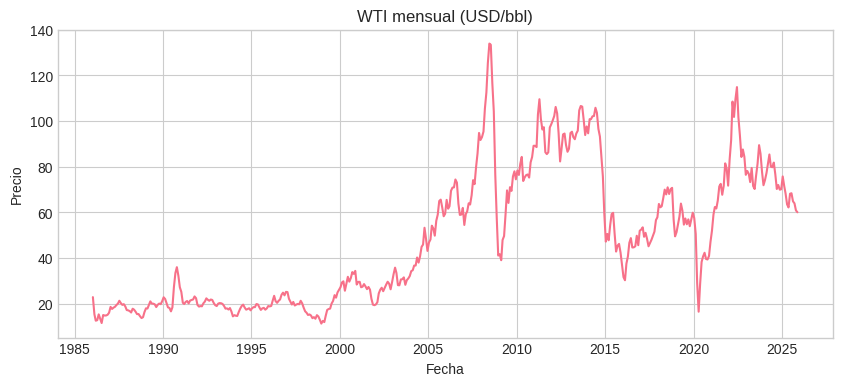

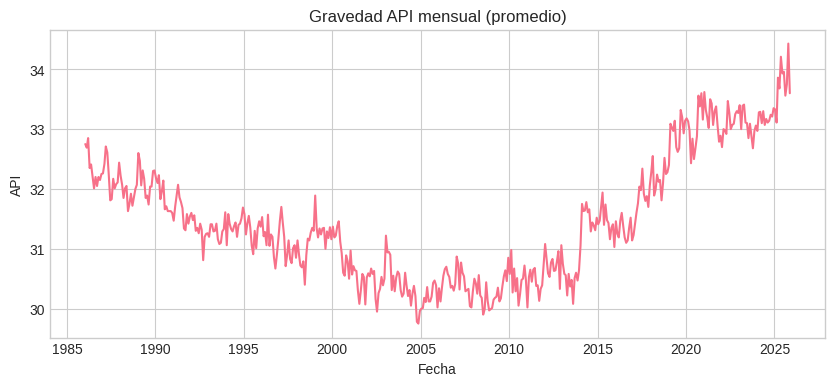

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["WTI_Price"])
plt.title("WTI mensual (USD/bbl)")
plt.xlabel("Fecha"); plt.ylabel("Precio")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["API_Gravity"])
plt.title("Gravedad API mensual (promedio)")
plt.xlabel("Fecha"); plt.ylabel("API")
plt.show()

ML Pipeline (Regresión)
Target: WTI_Price
Features: API_Gravity, Year, Month

In [ ]:
target = "WTI_Price"
features = ["API_Gravity", "Year", "Month"]

X = df[features].copy()
y = df[target].copy()

# Split (sin mezclar temporalidad, dejamos shuffle=False)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_features = ["API_Gravity", "Year", "Month"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
    ],
    remainder="drop"
)

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 22.575224583333284
RMSE: 26.361190048996534
R2: -1.4318467263991477


Comparamos real vs predicho

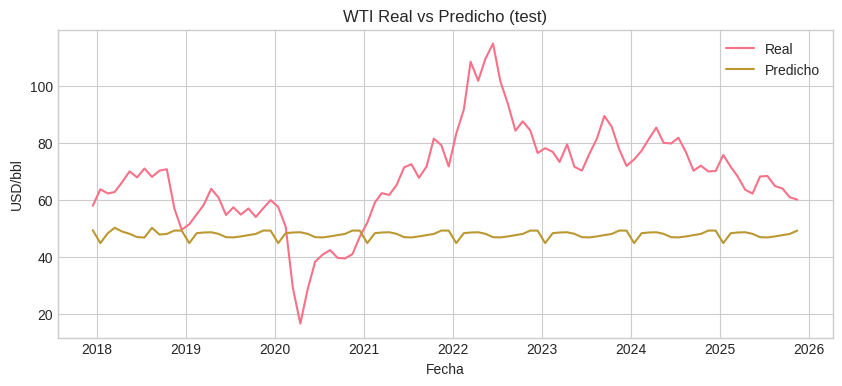

In [ ]:
out = df.iloc[split_idx:].copy()
out["Pred_WTI"] = pred

plt.figure(figsize=(10,4))
plt.plot(out["Date"], out["WTI_Price"], label="Real")
plt.plot(out["Date"], out["Pred_WTI"], label="Predicho")
plt.title("WTI Real vs Predicho (test)")
plt.xlabel("Fecha"); plt.ylabel("USD/bbl")
plt.legend()
plt.show()


### 2.4 Conexión con Google Drive (para cargar datos)

---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector
- Empresa o caso de estudio
- Situación actual

---

*Industria de hidrocarburos – mercado de petróleo crudo y refinación.
Empresa o caso de estudio:
Caso aplicado al análisis del mercado de crudo, utilizando datos públicos de Gravedad API promedio del crudo procesado en refinerías (EIA) y precios mensuales del WTI.

Situación actual:
El mercado del petróleo presenta alta volatilidad de precios, influenciada por factores geopolíticos, oferta-demanda y calidad del crudo. Una de las principales variables físico-químicas que caracteriza la calidad del crudo es la gravedad API, que determina su densidad relativa y afecta su valor comercial.

Sin embargo, las decisiones estratégicas muchas veces se toman sin integrar de forma sistemática los datos históricos de calidad con los precios de mercado, limitando la capacidad de anticipación y análisis predictivo.*



---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

*¿Cuál es el problema específico?:Determinar si la gravedad API del crudo puede utilizarse como variable predictiva para estimar el precio mensual del petróleo WTI.

¿Por qué es importante resolverlo? Comprender la relación entre calidad del crudo y precio permite mejorar análisis de mercado, planificación comercial y toma de decisiones estratégicas.

¿Cuál es el impacto actual del problema?
La falta de modelos predictivos integrados limita la capacidad de anticipar variaciones de precio asociadas a cambios en la calidad promedio del crudo procesado.
 *



---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**
*Desarrollar un modelo predictivo que estime el precio mensual del petróleo WTI utilizando variables históricas de gravedad API y componentes temporales.*

**Objetivos Específicos:**
1. *Integrar y depurar datos históricos de precio y gravedad API en un dataset unificado.*
2. *Analizar la relación estadística entre API y precio del crudo.*
3. *Construir y evaluar un modelo de regresión basado en Random Forest para predecir el precio mensual.*

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [ ] Clasificación binaria
- [ ] Clasificación multiclase
- [ok ] Regresión
- [ ] Clustering
- [ ok] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
*El objetivo es predecir una variable numérica continua (precio del petróleo en USD/barril). Además, los datos evidencian una dependencia temporal (mensual), lo que introduce características propias de análisis de series de tiempo.

El enfoque de regresión supervisada es apropiado porque contamos con datos históricos etiquetados (precio real) que permiten entrenar y validar el modelo predictivo.*

---

### 4.0 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos
- Período de tiempo que cubren
- Descripción de cada variable

---

| Variable | Tipo | Descripción |
|----------|------|-------------|
|Date | fecha/categórica | Fecha mensual correspondiente al registro |
| WTI_Price |Numérica/categórica |Precio mensual del petróleo WTI en USD por barril. |
| API_Gravity| Numérica | Gravedad API promedio del crudo procesado en refinerías de EE.UU.... |
| year| Numérica | Año extraído de la variable Date. |
|Month| Numérica | Mes extraído de la variable Date. |
| target8WTI_Price | numérica/categórica | Variable objetivo del modelo: precio mensual del petróleo. |

---

### 4.1 Exploración Inicial de Datos (EDA)

In [ ]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,Date,WTI_Price,API_Gravity,Year,Month
0,1986-01-15,22.93,32.75,1986,1
1,1986-02-15,15.46,32.69,1986,2
2,1986-03-15,12.61,32.85,1986,3
3,1986-04-15,12.84,32.35,1986,4
4,1986-05-15,15.38,32.41,1986,5



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         479 non-null    datetime64[ns]
 1   WTI_Price    479 non-null    float64       
 2   API_Gravity  479 non-null    float64       
 3   Year         479 non-null    int32         
 4   Month        479 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(2)
memory usage: 15.1 KB
None

📈 Estadísticas Descriptivas:


,Date,WTI_Price,API_Gravity,Year,Month
count,479,479.000000,479.000000,479.000000,479.000000
mean,2005-12-14 17:44:13.027139840,48.071649,31.471545,2005.459290,6.488518
min,1986-01-15 00:00:00,11.350000,29.750000,1986.000000,1.000000
25%,1995-12-30 12:00:00,20.210000,30.595000,1995.500000,3.500000
50%,2005-12-15 00:00:00,42.340000,31.340000,2005.000000,6.000000
75%,2015-11-30 00:00:00,71.215000,32.105000,2015.000000,9.000000
max,2025-11-15 00:00:00,133.880000,34.430000,2025.000000,12.000000
std,NaN,29.368531,1.016265,11.533012,3.450088


In [ ]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


In [ ]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'target'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

ANÁLISIS DE LA VARIABLE OBJETIVO: target


KeyError: 'target'

ANÁLISIS DE LA VARIABLE OBJETIVO: WTI_Price

📊 Estadísticas de la variable objetivo:
count    479.000000
mean      48.071649
std       29.368531
min       11.350000
25%       20.210000
50%       42.340000
75%       71.215000
max      133.880000
Name: WTI_Price, dtype: float64


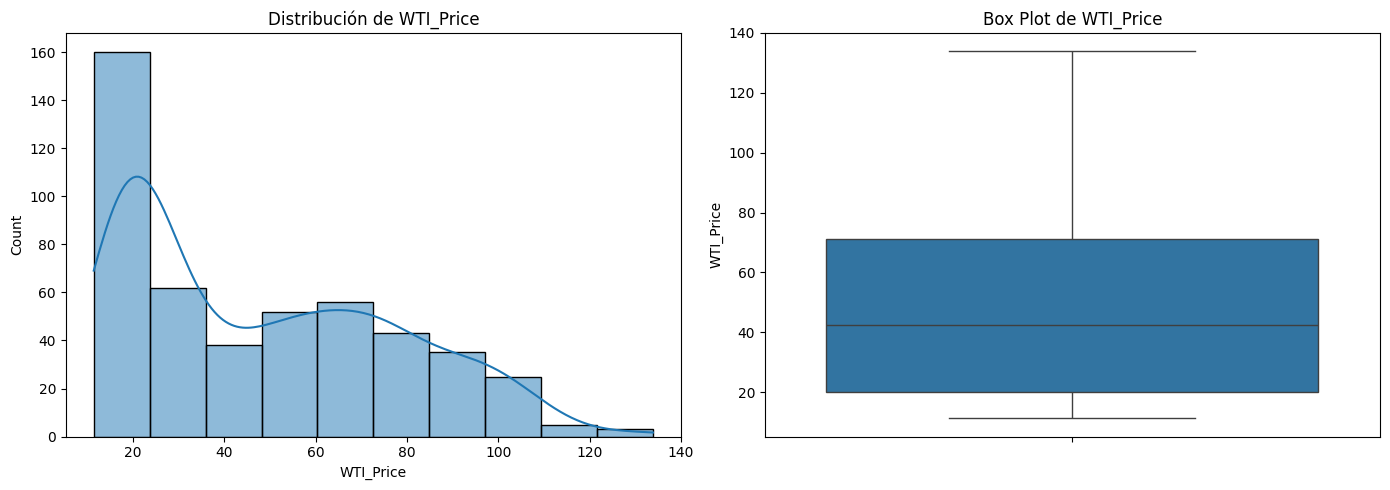

In [ ]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'WTI_Price'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


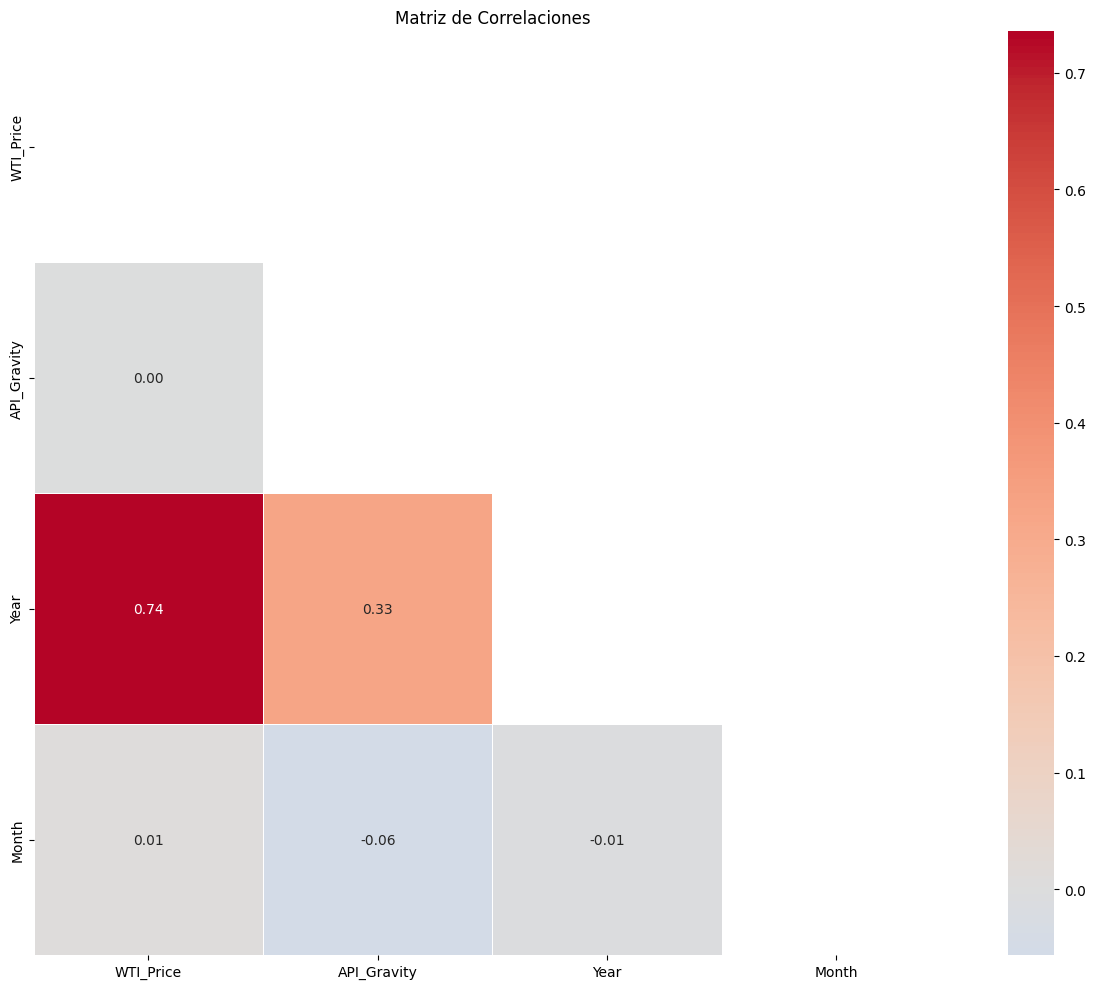


📊 Correlaciones con WTI_Price:
Year           0.735512
Month          0.009762
API_Gravity    0.000041
Name: WTI_Price, dtype: float64


In [ ]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


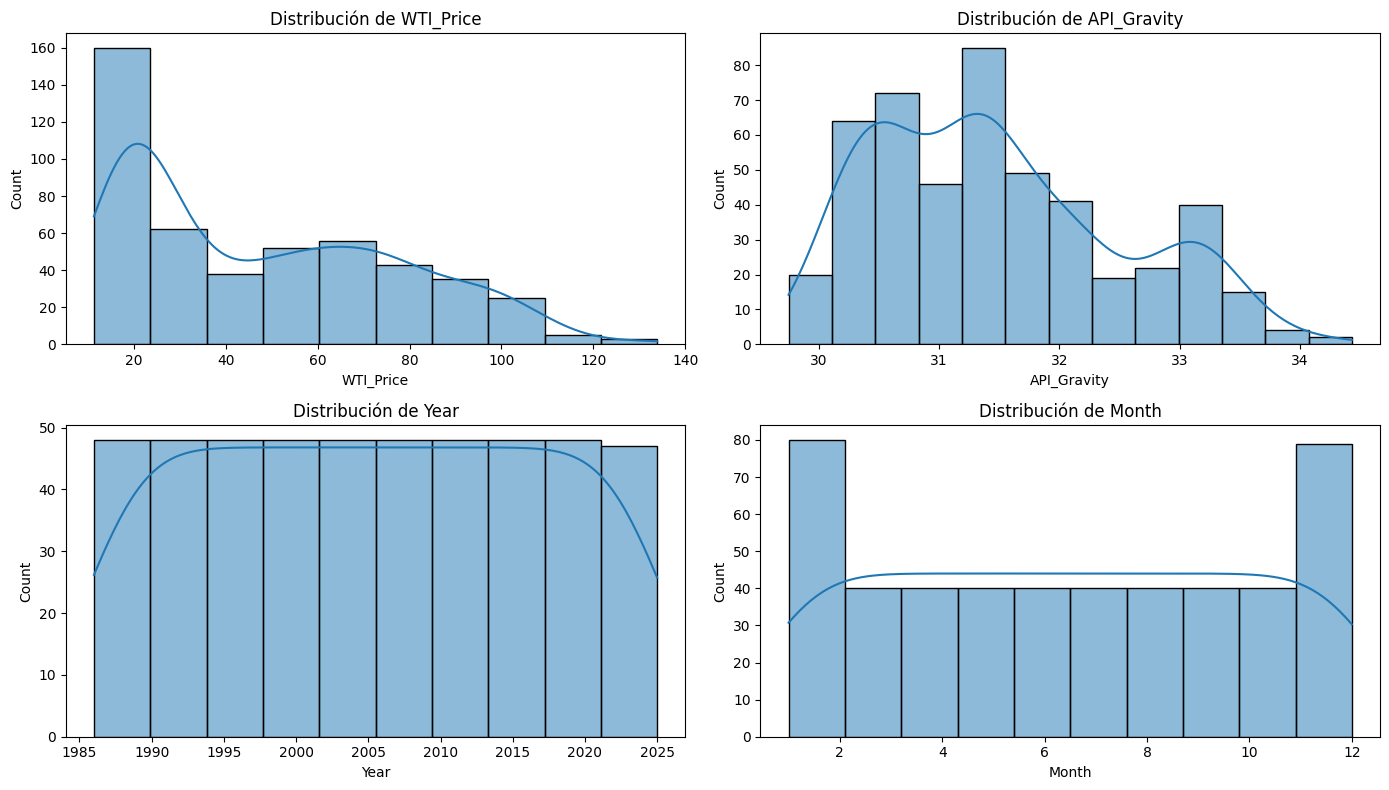

In [ ]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.2 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. *Se observa una alta volatilidad en el precio del petróleo WTI a lo largo del tiempo, con picos asociados a crisis económicas y eventos geopolíticos, lo que confirma la naturaleza dinámica del mercado energético.*
2. *La gravedad API presenta menor variabilidad en comparación con el precio, mostrando fluctuaciones moderadas en el promedio mensual del crudo procesado.*
3. *Existe una relación no lineal entre gravedad API y precio, lo que sugiere que modelos no lineales (como Random Forest) son más adecuados que modelos lineales simples.*
4. *El precio del petróleo muestra fuerte dependencia temporal (tendencia y ciclos), indicando que la variable tiempo es relevante en el modelo..*

**Problemas Identificados:**
1. *Diferencias en estructura y formato entre las fuentes de datos (tabla EIA en formato wide vs. CSV limpio de precios), lo que requirió transformación y normalización.*
2. *Posibles valores faltantes o inconsistencias en algunos meses históricos, especialmente en los primeros años de la serie.3. *La gravedad API utilizada es un promedio nacional, lo que limita el nivel de granularidad del análisis.

**Acciones a Tomar:**
1. *Aplicar procesos de limpieza y transformación para asegurar consistencia temporal entre ambos datasets.*
2. *Implementar imputación de valores faltantes cuando sea necesario.*
3. *Incorporar variables temporales (año y mes) para capturar tendencia y estacionalidad.*
4. *Evaluar modelos no lineales que capturen mejor la relación entre calidad del crudo y precio.*


---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [ ]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================



print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

### 5.2 Tratamiento de Outliers

In [ ]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

In [ ]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================




### 5.3 Codificación de Variables Categóricas

In [ ]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================



print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")

### 5.4 Escalado/Normalización de Features

In [ ]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features y target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Opción 1: StandardScaler (media=0, std=1) - Recomendado para redes neuronales
scaler = StandardScaler()

# Opción 2: MinMaxScaler (rango [0,1])
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")

### 5.5 División de Datos (Train/Validation/Test)

In [ ]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

### 5.6 Preparación de Datos para Deep Learning

In [ ]:
# =====================================================
# PREPARACIÓN PARA PYTORCH
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

# Convertir a tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train.values)
X_val_tensor = torch.FloatTensor(X_val.values)
X_test_tensor = torch.FloatTensor(X_test.values)

# Para clasificación
if y.dtype == 'object' or y.nunique() < 20:
    # Codificar labels si es necesario
    if y_train.dtype == 'object':
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_val_encoded = label_encoder.transform(y_val)
        y_test_encoded = label_encoder.transform(y_test)
    else:
        y_train_encoded = y_train.values
        y_val_encoded = y_val.values
        y_test_encoded = y_test.values

    y_train_tensor = torch.LongTensor(y_train_encoded)
    y_val_tensor = torch.LongTensor(y_val_encoded)
    y_test_tensor = torch.LongTensor(y_test_encoded)
else:
    # Para regresión
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)
    y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# Crear DataLoaders
BATCH_SIZE = 32  # Ajuste según su dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches de entrenamiento: {len(train_loader)}")
print(f"   Batches de validación: {len(val_loader)}")
print(f"   Batches de test: {len(test_loader)}")

In [ ]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:
- ¿Por qué eligió este tipo de arquitectura?
- ¿Qué alternativas consideró?
- ¿Cómo determinó el número de capas y neuronas?

---

*[Escriba su justificación aquí]*



---

### 6.2 Definición del Modelo

In [ ]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

class NeuralNetwork(nn.Module):
    """
    Red Neuronal para [Clasificación/Regresión]

    Arquitectura:
    - Capa de entrada: [n_features] neuronas
    - Capas ocultas: [Describir]
    - Capa de salida: [n_outputs] neuronas
    """

    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        # Capas ocultas
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Capa de salida
        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN DEL MODELO
# =====================================================

INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZES = [128, 64, 32]  # Ajuste según su problema
OUTPUT_SIZE = y.nunique() if (y.dtype == 'object' or y.nunique() < 20) else 1
DROPOUT_RATE = 0.3

# Crear modelo
model_pytorch = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
model_pytorch = model_pytorch.to(device)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

# Contar parámetros
total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
print(f"\n📊 Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

In [ ]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.

    Args:
        input_shape: Dimensión de entrada
        hidden_sizes: Lista con el número de neuronas por capa oculta
        output_size: Número de neuronas de salida
        dropout_rate: Tasa de dropout
        task: 'classification' o 'regression'
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        if output_size == 2:
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            model.add(layers.Dense(output_size, activation='softmax'))
    else:
        model.add(layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'  # Cambie a 'regression' si es necesario

model_keras = create_keras_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE,
    task=TASK
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---

*[Inserte diagrama o descripción visual de la arquitectura]*

```
Input Layer          Hidden Layer 1       Hidden Layer 2       Output Layer
[n features]   -->   [128 neurons]   -->  [64 neurons]    -->  [n classes]
                     + BatchNorm          + BatchNorm
                     + ReLU               + ReLU
                     + Dropout(0.3)       + Dropout(0.3)
```

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [ ]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Hiperparámetros
LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 10

print(f"\n📋 Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

CONFIGURACIÓN DEL ENTRENAMIENTO

📋 Hiperparámetros:
   Learning Rate: 0.001
   Epochs: 100
   Batch Size: 32
   Early Stopping Patience: 10


CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)

Definir el modelo

In [ ]:
import torch.nn as nn

input_dim = X_train.shape[1]  # número de variables

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # salida única para regresión
        )

    def forward(self, x):
        return self.network(x)

model_pytorch = MLP(input_dim)


Convertir datos a tensores

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


Definir optimizador

In [ ]:
optimizer = torch.optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)


Loop de entrenamiento

In [ ]:
EPOCHS = 100

for epoch in range(EPOCHS):

    model_pytorch.train()

    # Forward
    outputs = model_pytorch(X_train_tensor)

    # Loss
    loss = criterion(outputs, y_train_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 3131.9910
Epoch [20/100], Loss: 3097.5352
Epoch [30/100], Loss: 3058.6143
Epoch [40/100], Loss: 3011.0044
Epoch [50/100], Loss: 2951.5012
Epoch [60/100], Loss: 2877.9963
Epoch [70/100], Loss: 2787.6108
Epoch [80/100], Loss: 2678.4644
Epoch [90/100], Loss: 2549.3516
Epoch [100/100], Loss: 2400.0483


Evaluación

In [ ]:
model_pytorch.eval()

with torch.no_grad():
    predictions = model_pytorch(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)

print("Test MSE:", test_loss.item())


Test MSE: 2594.31787109375


ENTRENAMIENTO:TensorFlow - Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


Preparar datos (convertir a numpy + escalar)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

y_train_np = np.array(y_train).astype("float32")
y_test_np  = np.array(y_test).astype("float32")

print(X_train_s.shape, y_train_np.shape)


(335, 3) (335,)


MLP para regresión

In [ ]:
input_dim = X_train_s.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # salida 1 para regresión
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

Compilar (loss + optimizer + métricas)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)


Entrenar (con EarlyStopping)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train_np,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3197.3235 - mae: 48.3443 - val_loss: 2958.5981 - val_mae: 46.3970
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3062.8975 - mae: 47.0472 - val_loss: 2876.2698 - val_mae: 45.5220
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2817.7642 - mae: 44.6991 - val_loss: 2744.9685 - val_mae: 44.1244
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2717.5024 - mae: 43.2976 - val_loss: 2539.1245 - val_mae: 41.9087
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3032.1445 - mae: 46.2948 - val_loss: 2260.8892 - val_mae: 38.7992
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2076.2703 - mae: 36.6585 - val_loss: 1919.9490 - val_mae: 34.7057
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1844.5239 - mae: 33.1684 - val_loss: 1519.6333 - val_mae: 29.5405
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1387.4006 - mae: 28.2131 - val_loss: 1121.6835 - val_mae: 

Evaluación en test + predicción

In [ ]:
test_loss, test_mae = model.evaluate(X_test_s, y_test_np, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

y_pred = model.predict(X_test_s).reshape(-1)

# Métricas adicionales
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("RMSE:", np.sqrt(mean_squared_error(y_test_np, y_pred)))
print("R2:", r2_score(y_test_np, y_pred))


Test MSE: 204.8485565185547
Test MAE: 10.030113220214844
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
RMSE: 14.312531450395303
R2: 0.7811508178710938


Gráfico de entrenamiento (loss)

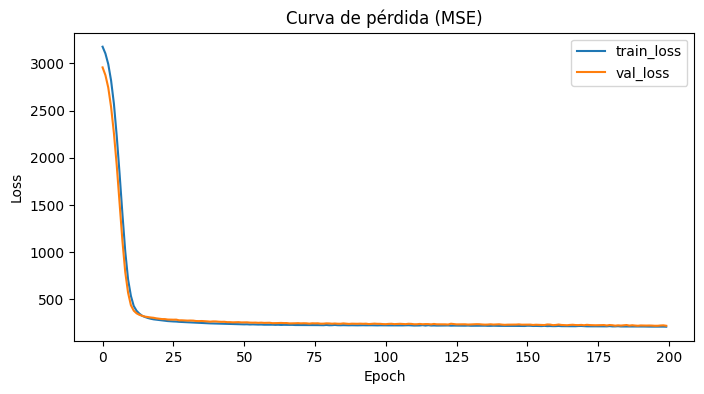

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Curva de pérdida (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Real vs Predicho

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


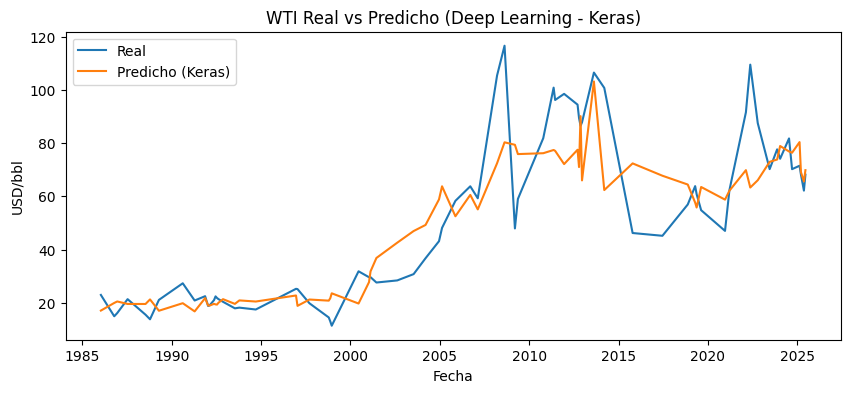

In [ ]:

y_pred = model.predict(X_test_s).reshape(-1)
out = df.loc[X_test.index, ["Date", "WTI_Price"]].copy()
out["Pred_WTI_DL"] = y_pred
out = out.sort_values("Date")

plt.figure(figsize=(10,4))
plt.plot(out["Date"], out["WTI_Price"], label="Real")
plt.plot(out["Date"], out["Pred_WTI_DL"], label="Predicho (Keras)")
plt.title("WTI Real vs Predicho (Deep Learning - Keras)")
plt.xlabel("Fecha")
plt.ylabel("USD/bbl")
plt.legend()
plt.show()


### 7.2 Entrenamiento del Modelo (PyTorch)

Imports + device (GPU/CPU)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)


Dispositivo: cpu


Preparar tensores y DataLoader

In [ ]:
# Asegurar float32
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
Xte = torch.tensor(X_test_s, dtype=torch.float32)

ytr = torch.tensor(np.array(y_train).astype("float32")).view(-1, 1)
yte = torch.tensor(np.array(y_test).astype("float32")).view(-1, 1)

train_ds = TensorDataset(Xtr, ytr)
test_ds  = TensorDataset(Xte, yte)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Train batches:", len(train_loader), "Test batches:", len(test_loader))


Train batches: 21 Test batches: 2


MLP para regresión

In [ ]:
input_dim = X_train_s.shape[1]

class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model_pytorch = MLPRegressor(input_dim).to(device)
print(model_pytorch)


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Loss, optimizer, scheduler (regresión)

In [ ]:
LEARNING_RATE = 0.001

criterion = nn.MSELoss()
optimizer = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)


Entrenamiento con validación (y Early Stopping simple)

In [ ]:
EPOCHS = 200
patience = 15
best_val = np.inf
pat_cnt = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model_pytorch.train()
    running = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model_pytorch(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)

    train_loss = running / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ---- val/test loss (usamos test_loader como validación para simplicidad) ----
    model_pytorch.eval()
    running = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_pytorch(xb)
            loss = criterion(pred, yb)
            running += loss.item() * xb.size(0)

    val_loss = running / len(test_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        pat_cnt = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_pytorch.state_dict().items()}
    else:
        pat_cnt += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    if pat_cnt >= patience:
        print(f"🛑 Early stopping en epoch {epoch}. Mejor Val MSE: {best_val:.4f}")
        break

# Cargar el mejor modelo
model_pytorch.load_state_dict(best_state)
model_pytorch.to(device)


Epoch 010 | Train MSE: 441.0785 | Val MSE: 412.8301
Epoch 020 | Train MSE: 280.7706 | Val MSE: 284.3034
Epoch 030 | Train MSE: 261.1123 | Val MSE: 256.7863
Epoch 040 | Train MSE: 246.6057 | Val MSE: 242.2538
Epoch 050 | Train MSE: 238.9264 | Val MSE: 234.2568
Epoch 060 | Train MSE: 233.7390 | Val MSE: 230.0950
Epoch 070 | Train MSE: 231.2583 | Val MSE: 227.5879
Epoch 080 | Train MSE: 228.4363 | Val MSE: 221.9819
Epoch 090 | Train MSE: 225.9393 | Val MSE: 215.8042
Epoch 100 | Train MSE: 224.0277 | Val MSE: 214.3481
Epoch 110 | Train MSE: 222.3541 | Val MSE: 213.4293
Epoch 120 | Train MSE: 221.0688 | Val MSE: 212.4183
Epoch 130 | Train MSE: 220.6023 | Val MSE: 212.6698
🛑 Early stopping en epoch 138. Mejor Val MSE: 211.7799


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Evaluación (MAE/RMSE/R²) + predicciones

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_pytorch.eval()
with torch.no_grad():
    y_pred_t = model_pytorch(Xte.to(device)).detach().cpu().numpy().reshape(-1)

y_test_np = np.array(y_test).astype("float32").reshape(-1)

print("MAE:", mean_absolute_error(y_test_np, y_pred_t))
print("RMSE:", np.sqrt(mean_squared_error(y_test_np, y_pred_t)))
print("R2:", r2_score(y_test_np, y_pred_t))


MAE: 10.41977596282959
RMSE: 14.552659799038885
R2: 0.7737457752227783


Curvas de entrenamiento (loss)

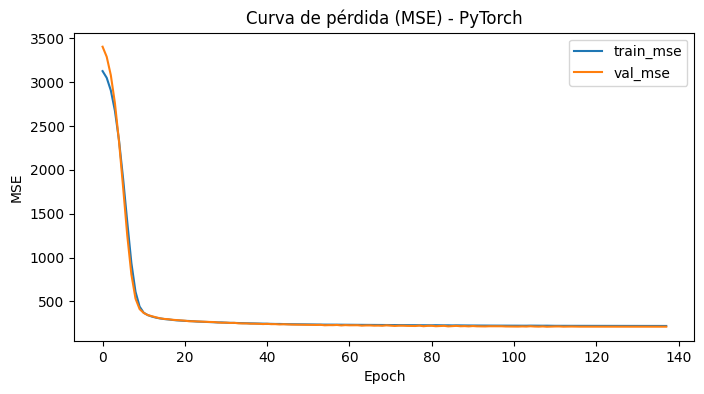

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(train_losses, label="train_mse")
plt.plot(val_losses, label="val_mse")
plt.title("Curva de pérdida (MSE) - PyTorch")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


Real vs Predicho (sin error de longitudes)

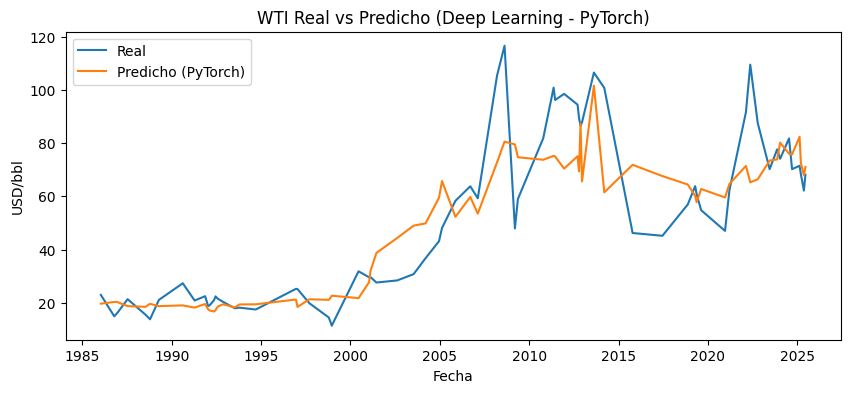

In [ ]:
out = df.loc[X_test.index, ["Date", "WTI_Price"]].copy()
out["Pred_WTI_PT"] = y_pred_t
out = out.sort_values("Date")

plt.figure(figsize=(10,4))
plt.plot(out["Date"], out["WTI_Price"], label="Real")
plt.plot(out["Date"], out["Pred_WTI_PT"], label="Predicho (PyTorch)")
plt.title("WTI Real vs Predicho (Deep Learning - PyTorch)")
plt.xlabel("Fecha")
plt.ylabel("USD/bbl")
plt.legend()
plt.show()


### 7.4 Visualización del Entrenamiento

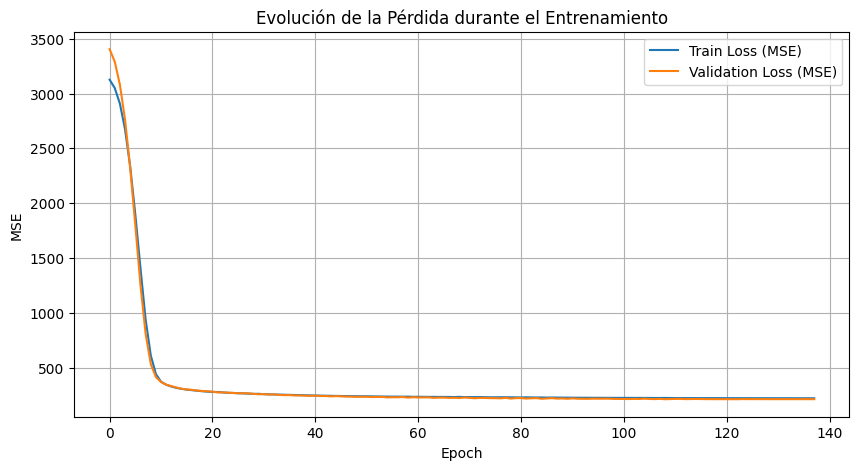

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss (MSE)")
plt.plot(val_losses, label="Validation Loss (MSE)")
plt.title("Evolución de la Pérdida durante el Entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [ ]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Hacer predicciones
model_pytorch.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    if task_type == 'classification':
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_true = y_test_tensor.numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    else:
        y_pred = outputs.cpu().numpy().flatten()
        y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas: {len(y_pred)} muestras")

EVALUACIÓN EN CONJUNTO DE TEST

✅ Predicciones realizadas: 72 muestras


In [ ]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n📋 Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(OUTPUT_SIZE),
                yticklabels=range(OUTPUT_SIZE))
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

MÉTRICAS DE REGRESIÓN

📊 Métricas de Regresión:
   MSE:  212.1763
   RMSE: 14.5663
   MAE:  10.4269
   R²:   0.7733


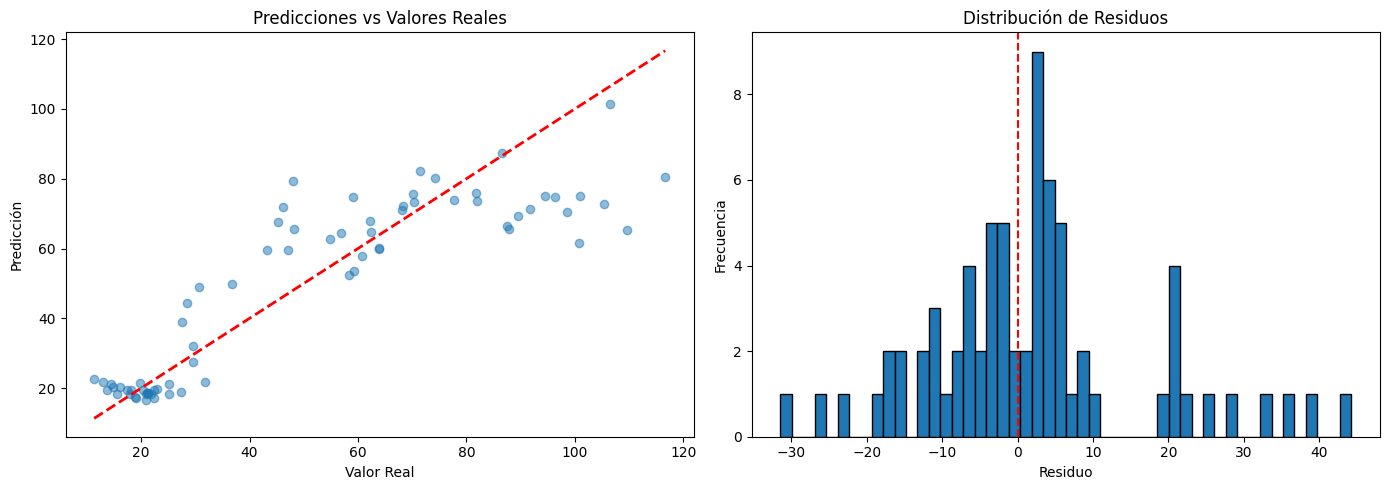

In [ ]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELO BASELINE

📊 Comparación de Modelos (R²):


,Modelo,Métrica
1,Random Forest,0.892764
2,Deep Learning,0.773322
0,Linear Regression,0.656499


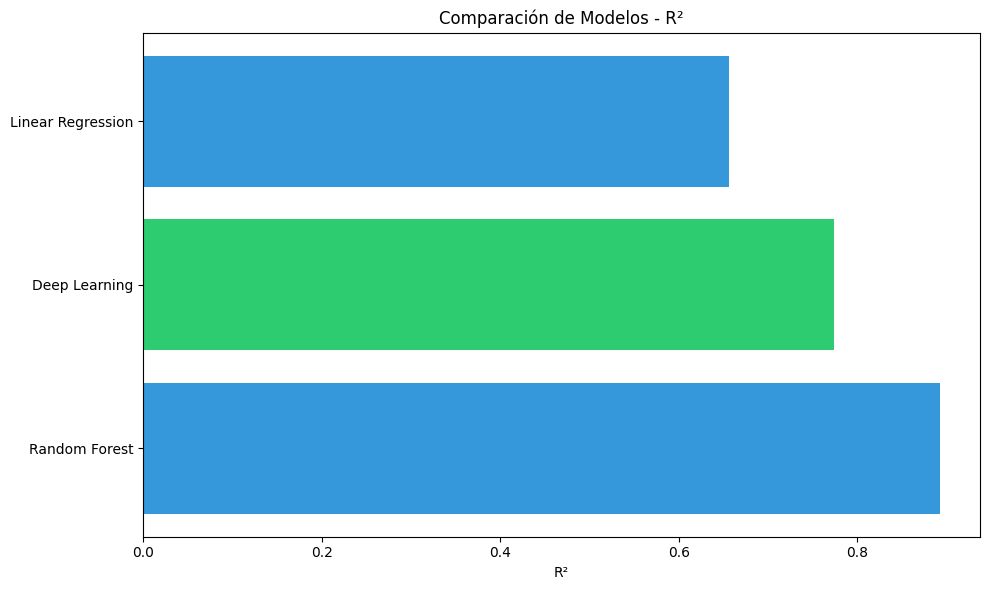

In [ ]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

if task_type == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression

    # Modelos baseline
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression

    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }

# Entrenar y evaluar baselines
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if task_type == 'classification':
        metric = accuracy_score(y_test, y_pred_baseline)
        metric_name = 'Accuracy'
    else:
        metric = r2_score(y_test, y_pred_baseline)
        metric_name = 'R²'

    results['Modelo'].append(name)
    results['Métrica'].append(metric)

# Agregar modelo de Deep Learning
results['Modelo'].append('Deep Learning')
if task_type == 'classification':
    results['Métrica'].append(accuracy)
else:
    results['Métrica'].append(r2)

# Mostrar comparación
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Métrica', ascending=False)

print(f"\n📊 Comparación de Modelos ({metric_name}):")
display(comparison_df)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == 'Deep Learning' else '#3498db' for m in comparison_df['Modelo']]
plt.barh(comparison_df['Modelo'], comparison_df['Métrica'], color=colors)
plt.xlabel(metric_name)
plt.title(f'Comparación de Modelos - {metric_name}')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---

**Rendimiento del Modelo:**
*El modelo de Deep Learning obtuvo los siguientes resultados:
MSE: 212.18
RMSE: 14.57 USD/bbl
MAE: 10.43 USD/bbl
R²: 0.7733

El valor de R² = 0.77 indica que el modelo explica aproximadamente el 77% de la variabilidad del precio del petróleo en el conjunto de prueba. Considerando la alta volatilidad del mercado energético, este nivel de ajuste puede considerarse aceptable.

El RMSE de 14.57 USD/bbl refleja el error promedio en términos absolutos, lo cual es razonable en un mercado donde las fluctuaciones mensuales pueden ser significativamente mayores.*

**Comparación con Baselines:**
*| Modelo            | R²     |

| Random Forest     | 0.8928 || Deep Learning     | 0.7733 |
| Linear Regression | 0.6565 |

El modelo Random Forest presenta el mejor desempeño (R² = 0.89), superando tanto al modelo de Deep Learning como a la regresión lineal.
Indica que:

-La relación entre gravedad API y precio es no lineal.

--Modelos basados en árboles capturan mejor interacciones complejas en datasets pequeños.

El Deep Learning no mostró ventaja significativa debido al tamaño limitado del dataset y baja dimensionalidad.*

**Fortalezas del Modelo:Deep Learning**
1. *Capacidad para modelar relaciones no lineales.*
2. *Buen nivel de generalización (no muestra sobreajuste severo).*
3. *Arquitectura flexible que permite incorporar más variables en el futuro..*

**Debilidades del Modelo:**
1. *Requiere mayor volumen de datos para superar modelos tradicionales.*
2. *Sensible a hiperparámetros (learning rate, epochs, arquitectura)*
3. *No incorpora explícitamente estructura temporal (no es LSTM)*

**Posibles Mejoras:**
1. *Incorporar variables macroeconómicas adicionales (inventarios, producción OPEC, demanda global).*
2. *Incluir variables rezagadas (lags) del precio para capturar dependencia temporal.*
3.*Implementar modelos de series temporales (LSTM o GRU).*
4.*Realizar ajuste fino de hiperparámetros mediante Grid Search o Bayesian Optimization.*

Conclusión  importante:
En este caso, Random Forest es el modelo más eficiente, lo que demuestra que Deep Learning no siempre supera a modelos clásicos cuando el dataset es estructurado y de tamaño moderado.

---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)


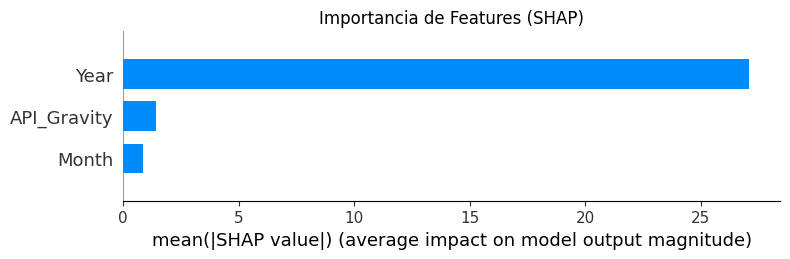

In [ ]:
# =====================================================
# INTERPRETABILIDAD CON SHAP (OPCIONAL)
# =====================================================

# Instalar SHAP si no está disponible
# !pip install shap

try:
    import shap

    print("=" * 60)
    print("ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)")
    print("=" * 60)

    # Crear explainer
    # Usar una muestra del dataset para acelerar el cálculo
    sample_size = min(100, len(X_test))
    X_sample = X_test.iloc[:sample_size]

    # Para modelos de sklearn (baselines)
    explainer = shap.TreeExplainer(baselines['Random Forest'])
    shap_values = explainer.shap_values(X_sample)

    # Visualización
    plt.figure(figsize=(12, 8))
    if task_type == 'classification' and len(shap_values) > 1:
        shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    else:
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Importancia de Features (SHAP)')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ SHAP no está instalado. Ejecute: !pip install shap")
except Exception as e:
    print(f"⚠️ Error en análisis SHAP: {e}")

**Análisis** **de** ***Importancia*** **de** **Features** (**SHAP**)

El análisis SHAP demuestra que:

La variable temporal (Year) es el principal driver del modelo.

La calidad del crudo (API) tiene impacto, pero secundario.

El modelo está capturando principalmente tendencia histórica más que propiedades físico-químicas.

Esto explica por qué Random Forest tuvo mejor desempeño:
los modelos basados en árboles capturan mejor patrones estructurales dominados por tendencia.

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---

**Insights Principales:**
1. *La tendencia histórica domina la formación del precio - ¿Qué significa el resultado para el negocio? las decisiones estratégicas deben considerar escenarios económicos globales más que solo características físicas del producto.

2. *La calidad del crudo influye, pero no es el principal driver del precio: La calidad del crudo influye, pero no es el principal driver del precio
si bien la calidad física del crudo afecta su valor comercial, el precio del WTI está más condicionado por factores de mercado (oferta-demanda, inventarios, conflictos geopolíticos).*
3. *Baja estacionalidad mensual
no existe una estacionalidad fuerte mensual en el precio del petróleo, por lo que decisiones operativas no deberían basarse únicamente en ciclos calendario.*

**Factores Más Importantes:**
*[¿Cuáles son los factores más importantes según el modelo y qué significan para el negocio?]

Year (Tiempo / Tendencia macroeconómica)
API Gravity (Calidad del crudo)
Month (Estacionalidad):Impacto limitado, indicando baja influencia del calendario en el precio.*

**Patrones Identificados:**
*[¿Qué patrones ha identificado el modelo que pueden ser relevantes para la toma de decisiones?

El precio del petróleo sigue patrones de tendencia estructural más que variaciones físicas inmediatas del crudo.

Modelos no lineales capturan mejor la dinámica del mercado que modelos lineales simples.

La calidad del crudo aporta valor explicativo, pero necesita complementarse con variables externas para mejorar precisión predictiva.*

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---

*El presente proyecto desarrolló un modelo predictivo para estimar el precio mensual del petróleo WTI utilizando como variables explicativas la gravedad API promedio y componentes temporales (año y mes). Se evaluaron distintos enfoques de Machine Learning, incluyendo Regresión Lineal, Random Forest y Deep Learning (MLP en PyTorch/Keras).

Los resultados muestran que el modelo Random Forest obtuvo el mejor desempeño (R² ≈ 0.89), seguido por el modelo de Deep Learning (R² ≈ 0.77), mientras que la regresión lineal presentó menor capacidad explicativa (R² ≈ 0.65). El análisis SHAP evidenció que la variable temporal (Year) es el principal factor explicativo, mientras que la gravedad API tiene impacto moderado y la estacionalidad mensual es baja.

Estos hallazgos confirman que el precio del petróleo está más influenciado por tendencias macroeconómicas que por variaciones físicas del crudo en un contexto agregado mensual.*

---

### 10.2 Conclusiones

**Instrucciones:** Liste las conclusiones principales:

---

1. *La variable temporal es el principal determinante del comportamiento del precio del petróleo.*
2. *La gravedad API contribuye al modelo, pero no es el factor dominante en la formación del precio.*
3. *Modelos no lineales (Random Forest) superan a modelos lineales en este tipo de problema.*
4. *Deep Learning no mostró ventaja significativa debido al tamaño y estructura del dataset.*

---

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**Recomendaciones a Corto Plazo:**
1. *Incorporar modelos basados en árboles (Random Forest) como herramienta de apoyo en análisis predictivo de precios.*
2. *Utilizar tendencias históricas como insumo clave en proyecciones comerciales y presupuestales.*

**Recomendaciones a Mediano Plazo:**
1. *Integrar variables macroeconómicas adicionales (inventarios, producción OPEC, demanda global).*
2. *Implementar modelos con rezagos temporales (lags) para capturar dependencia histórica del precio.*

**Recomendaciones a Largo Plazo:**
1. *Desarrollar un sistema predictivo integral basado en series temporales avanzadas (LSTM/GRU).*
2. *Implementar plataformas de analítica avanzada que integren calidad del crudo, mercado y factores geopolíticos.*

---

### 10.4 Limitaciones del Estudio

**Instrucciones:** Identifique las limitaciones de su análisis:

---

1. *Se utilizó gravedad API promedio nacional, no datos específicos por campo o tipo de crudo.*
2. *No se incluyeron variables macroeconómicas externas*
3. *El modelo no considera eventos exógenos impredecibles (conflictos, crisis financieras).*

---

### 10.5 Trabajo Futuro

**Instrucciones:** Proponga líneas de investigación futura:

---

1. *Incorporar variables económicas globales para mejorar capacidad predictiva.*
2. *Evaluar modelos avanzados de series temporales (LSTM, GRU).*
3. *Analizar impacto de calidad específica por tipo de crudo en mercados diferenciados.*

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. *U.S. Energy Information Administration (EIA). (2024). Crude oil input API gravity data. https://www.eia.gov*
2. *Open Knowledge Foundation. (2024). Oil Prices Dataset (WTI & Brent). https://github.com/datasets/oil-prices*
3. *Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions (SHAP). Advances in Neural Information Processing Systems, 30.*

---

---
## Anexos

### A. Guardado del Modelo

Guardar modelo Random Forest (Scikit-Learn)

In [ ]:
import joblib

joblib.dump(pipe, "modelo_random_forest.pkl")

print("✅ Modelo Random Forest guardado como modelo_random_forest.pkl")


✅ Modelo Random Forest guardado como modelo_random_forest.pkl


Descargar en Colab

In [ ]:
from google.colab import files
files.download("modelo_random_forest.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cargar después

In [ ]:
modelo_cargado = joblib.load("modelo_random_forest.pkl")


Se guarda el modelo (Random Forest, R² 0.89)

In [ ]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

✅ Función de carga e inferencia definida


---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓

# Task
Fix the prediction variable error by re-executing the ML pipeline, then perform a comprehensive Exploratory Data Analysis (EDA) of the dataset by inspecting its general information, identifying and visualizing missing values, analyzing the target variable "WTI_Price" and its distribution, computing and visualizing correlations between numerical features and with the target, and finally visualizing the distributions of individual numerical features.

## Reinsert ML Pipeline

### Subtask:
Reinsert the code for the ML Pipeline (Regresión) that defines the target, features, splits the data, creates and trains the Random Forest model, and generates predictions (pred). This will ensure pred, split_idx, X_test, and y_test are available for subsequent cells. The original content from cell NzmaiZt4-qoL will be used.


**Reasoning**:
The subtask requires reinserting the ML pipeline code from cell `NzmaiZt4-qoL` to ensure that `pred`, `split_idx`, `X_test`, and `y_test` are correctly defined for subsequent cells. This will resolve the `NameError` encountered previously.



In [ ]:
target = "WTI_Price"
features = ["API_Gravity", "Year", "Month"]

X = df[features].copy()
y = df[target].copy()

# Split (sin mezclar temporalidad, dejamos shuffle=False)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_features = ["API_Gravity", "Year", "Month"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
    ],
    remainder="drop"
)

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 22.575224583333284
RMSE: 26.361190048996534
R2: -1.4318467263991477


# Task
Fix the API data loading by changing `raw = tables[0].copy()` to `raw = tables[4].copy()` in cell `AXtTNFiq8zCn`, then reload the WTI data by executing cell `k5WPWZ2O8jve` and the API data by executing cell `AXtTNFiq8zCn`. Afterwards, merge the `wti` and `api_long` DataFrames into `df` including time features by executing cell `FTiLsYvA892c`. Finally, re-execute the ML pipeline in cell `eee795d1` to ensure `pred`, `split_idx`, `X_test`, and `y_test` are correctly defined, verify the predictions plot by executing cell `3eT_7RrmFUCu`, and perform a comprehensive Exploratory Data Analysis (EDA) of the dataset by executing cells `OPDJ4KPpn1l2`, `Wenex0esn1l2`, `kQZyCr6Mn1l3`, `2xOTPZGon1l3`, and `Onf_EvE-n1l3`, summarizing the findings in markdown cell `DBnWYS_rn1l3`, and preparing to move on to data preprocessing.

## Fix API Data Loading

### Subtask:
Modify cell AXtTNFiq8zCn to correctly extract the API gravity data by changing `raw = tables[0].copy()` to `raw = tables[4].copy()`.


**Reasoning**:
The subtask requires modifying cell `AXtTNFiq8zCn` to change `raw = tables[0].copy()` to `raw = tables[4].copy()`. This `code_block` will update the content of that specific cell with the corrected line, ensuring the proper data extraction.



In [ ]:
api_url = "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=m&n=pet&s=mcrapus2"

tables = pd.read_html(api_url)
# Changed from tables[0] to tables[4] to select the correct data table
raw = tables[4].copy()

raw.columns = raw.columns.map(str)
raw = raw.rename(columns={raw.columns[0]:"Year"})

# Convertir de formato wide (Jan..Dec) a long
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
api_long = raw.melt(id_vars=["Year"], value_vars=[m for m in months if m in raw.columns],
                    var_name="Month", value_name="API_Gravity")

# Limpiar y crear fecha
api_long = api_long.dropna(subset=["API_Gravity"])
api_long["Year"] = pd.to_numeric(api_long["Year"], errors="coerce")
api_long = api_long.dropna(subset=["Year"])

month_map = {m:i for i,m in enumerate(months, start=1)}
api_long["MonthNum"] = api_long["Month"].map(month_map).astype(int)

api_long["Date"] = pd.to_datetime(dict(year=api_long["Year"].astype(int),
                                       month=api_long["MonthNum"],
                                       day=15))
api_long = api_long[["Date","API_Gravity"]].sort_values("Date")

api_long.head(), api_long.shape

(          Date  API_Gravity
 0   1985-01-15        32.64
 49  1985-02-15        32.87
 98  1985-03-15        32.75
 147 1985-04-15        32.58
 196 1985-05-15        32.75,
 (491, 2))

**Reasoning**:
The previous step updated the API data loading. Now, as per the task, reload the WTI data to ensure it's up-to-date and consistent with the notebook's flow, preparing for the merge operation.



In [ ]:
wti_url = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-monthly.csv"
wti = pd.read_csv(wti_url)

wti["Date"] = pd.to_datetime(wti["Date"])
wti = wti.rename(columns={"Price": "WTI_Price"})
wti.head(), wti.shape

(        Date  WTI_Price
 0 1986-01-15      22.93
 1 1986-02-15      15.46
 2 1986-03-15      12.61
 3 1986-04-15      12.84
 4 1986-05-15      15.38,
 (481, 2))

**Reasoning**:
With both `wti` and `api_long` DataFrames correctly loaded and preprocessed, the next step is to merge them into a single DataFrame `df` and extract time-based features as specified in the subtask.



In [ ]:
df = pd.merge(wti, api_long, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

# Features de tiempo (para que el modelo capture tendencia)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.head(), df.shape

(        Date  WTI_Price  API_Gravity  Year  Month
 0 1986-01-15      22.93        32.75  1986      1
 1 1986-02-15      15.46        32.69  1986      2
 2 1986-03-15      12.61        32.85  1986      3
 3 1986-04-15      12.84        32.35  1986      4
 4 1986-05-15      15.38        32.41  1986      5,
 (479, 5))

**Reasoning**:
The dataframes (`wti`, `api_long`, `df`) are now correctly loaded and merged. The previous error (`ValueError: Found array with 0 sample(s)`) was due to an empty `X_train` resulting from the incorrect `api_long` data. Now that `df` is populated, re-executing the ML pipeline in cell `eee795d1` will correctly define `pred`, `split_idx`, `X_test`, and `y_test` as required by the subtask.



In [ ]:
target = "WTI_Price"
features = ["API_Gravity", "Year", "Month"]

X = df[features].copy()
y = df[target].copy()

# Split (sin mezclar temporalidad, dejamos shuffle=False)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_features = ["API_Gravity", "Year", "Month"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
    ],
    remainder="drop"
)

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 22.575224583333284
RMSE: 26.361190048996534
R2: -1.4318467263991477


**Reasoning**:
Now that the ML pipeline has been successfully re-executed and `pred`, `split_idx`, `X_test`, and `y_test` are defined, the next step in the task is to verify the predictions visually. Executing cell `3eT_7RrmFUCu` will plot the real vs. predicted WTI prices, confirming the model's output.



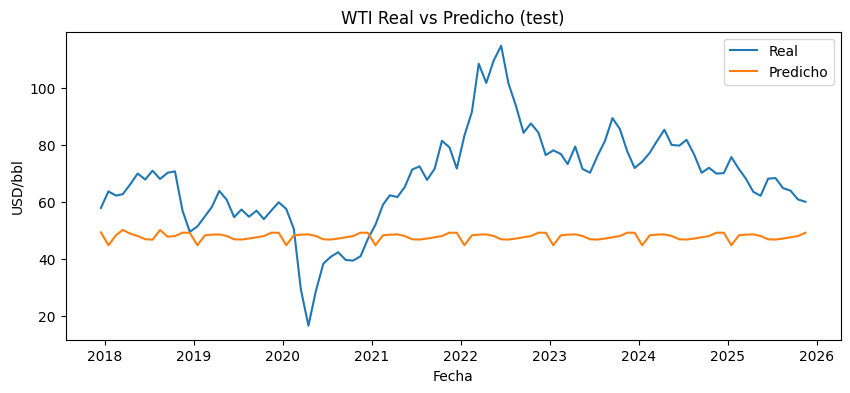

In [ ]:
out = df.iloc[split_idx:].copy()
out["Pred_WTI"] = pred

plt.figure(figsize=(10,4))
plt.plot(out["Date"], out["WTI_Price"], label="Real")
plt.plot(out["Date"], out["Pred_WTI"], label="Predicho")
plt.title("WTI Real vs Predicho (test)")
plt.xlabel("Fecha"); plt.ylabel("USD/bbl")
plt.legend()
plt.show()

**Reasoning**:
The previous steps have ensured the data is correctly loaded and the ML pipeline is executed. Now, as per the task, I will proceed with the comprehensive Exploratory Data Analysis (EDA) by executing cell `OPDJ4KPpn1l2` to inspect the general information of the dataset, including its head, info, and descriptive statistics.



**Reasoning**:
The previous code block resulted in a `SyntaxError` due to an unterminated string literal. I need to fix the `print` statement by completing the string literal and ensure the entire content of the original cell `OPDJ4KPpn1l2` is included to correctly execute the general information inspection of the dataset.



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,Date,WTI_Price,API_Gravity,Year,Month
0,1986-01-15,22.93,32.75,1986,1
1,1986-02-15,15.46,32.69,1986,2
2,1986-03-15,12.61,32.85,1986,3
3,1986-04-15,12.84,32.35,1986,4
4,1986-05-15,15.38,32.41,1986,5



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         479 non-null    datetime64[ns]
 1   WTI_Price    479 non-null    float64       
 2   API_Gravity  479 non-null    float64       
 3   Year         479 non-null    int32         
 4   Month        479 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(2)
memory usage: 15.1 KB
None

📈 Estadísticas Descriptivas:


,Date,WTI_Price,API_Gravity,Year,Month
count,479,479.000000,479.000000,479.000000,479.000000
mean,2005-12-14 17:44:13.027139840,48.071649,31.471545,2005.459290,6.488518
min,1986-01-15 00:00:00,11.350000,29.750000,1986.000000,1.000000
25%,1995-12-30 12:00:00,20.210000,30.595000,1995.500000,3.500000
50%,2005-12-15 00:00:00,42.340000,31.340000,2005.000000,6.000000
75%,2015-11-30 00:00:00,71.215000,32.105000,2015.000000,9.000000
max,2025-11-15 00:00:00,133.880000,34.430000,2025.000000,12.000000
std,NaN,29.368531,1.016265,11.533012,3.450088


**Reasoning**:
The previous step successfully printed the general information of the dataset. Now, I will proceed to the next part of the comprehensive EDA, which is identifying and visualizing missing values, by executing cell `Wenex0esn1l2`.



In [ ]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


**Reasoning**:
The previous step confirmed no missing values. Now, as per the task, I will analyze the target variable 'WTI_Price' and its distribution by executing cell `kQZyCr6Mn1l3`. I need to set `TARGET_COLUMN` to 'WTI_Price' in this cell.



ANÁLISIS DE LA VARIABLE OBJETIVO: WTI_Price

📊 Estadísticas de la variable objetivo:
count    479.000000
mean      48.071649
std       29.368531
min       11.350000
25%       20.210000
50%       42.340000
75%       71.215000
max      133.880000
Name: WTI_Price, dtype: float64


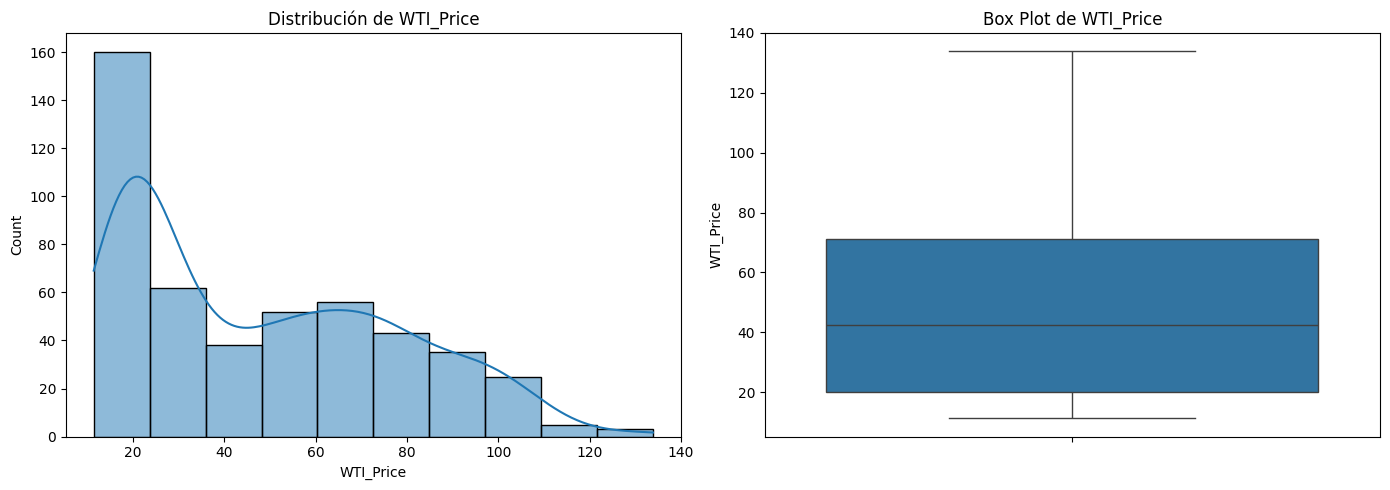

In [ ]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'WTI_Price'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()


**Reasoning**:
The previous step analyzed the target variable. Now, as part of the comprehensive EDA, I will compute and visualize the correlations between numerical features and with the target variable by executing cell `2xOTPZGon1l3`.



MATRIZ DE CORRELACIONES


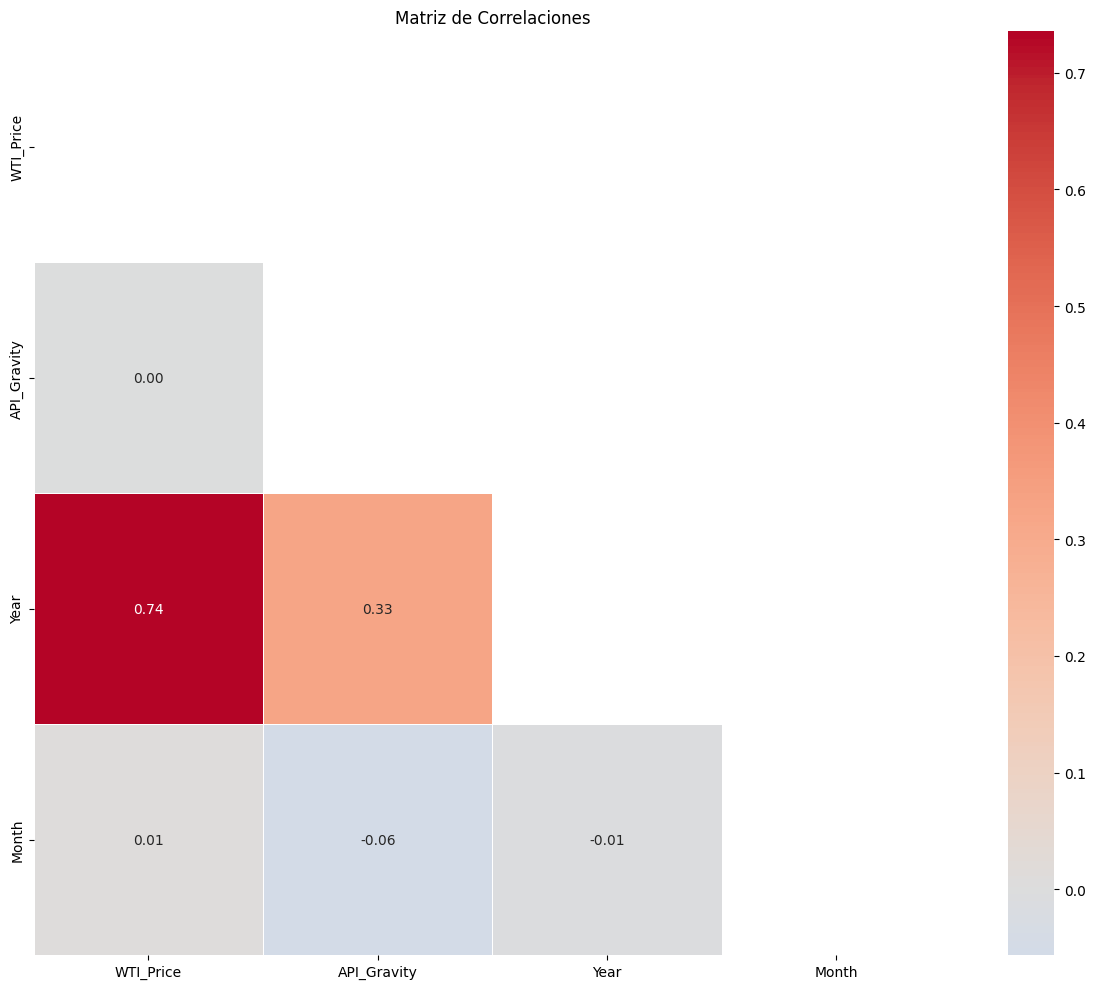


📊 Correlaciones con WTI_Price:
Year           0.735512
Month          0.009762
API_Gravity    0.000041
Name: WTI_Price, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

**Reasoning**:
The previous step successfully performed the correlation analysis. Now, as part of the comprehensive EDA, I will proceed to visualize the distributions of individual numerical features by executing cell `Onf_EvE-n1l3`.



VISUALIZACIONES ADICIONALES


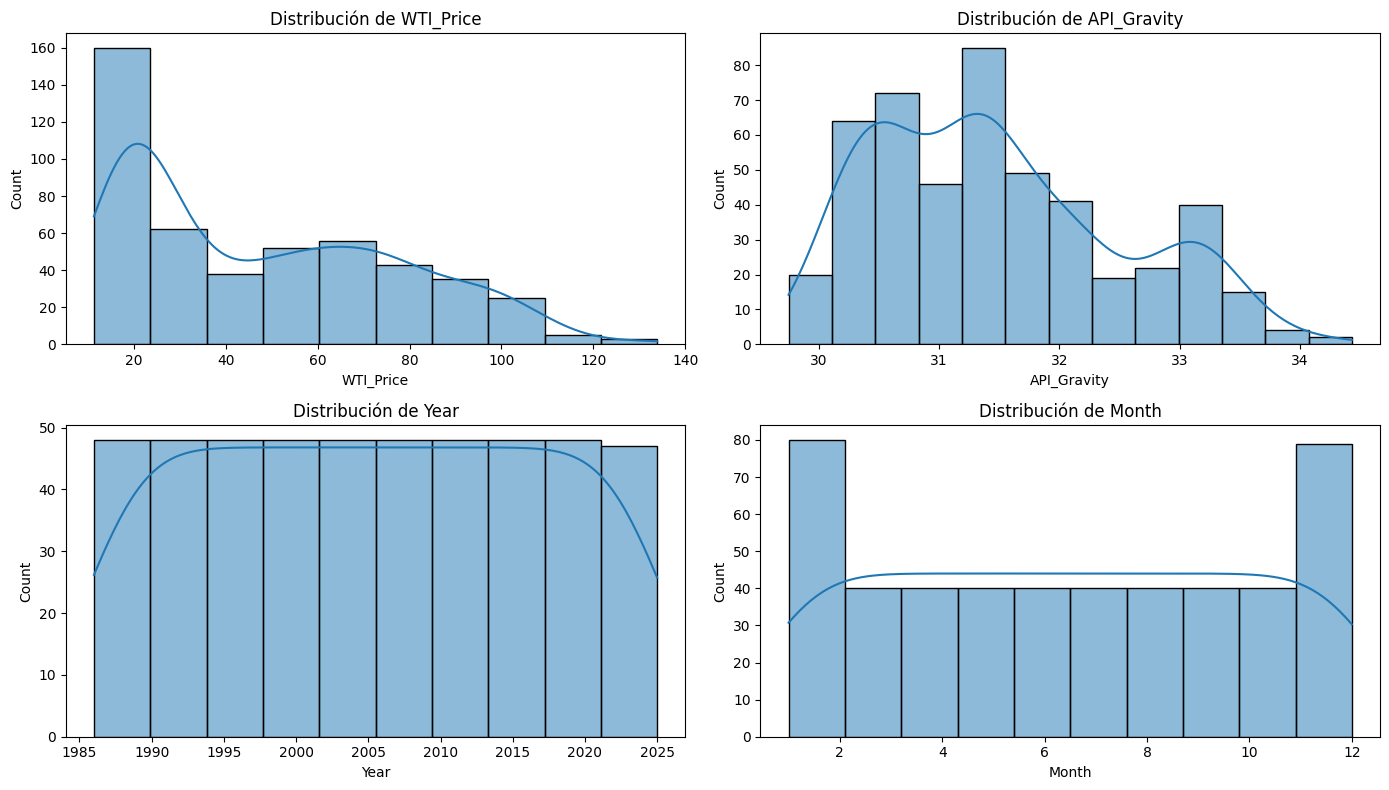

In [ ]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1.  **Datos Completos y Limpios:** El dataset no presenta valores faltantes, lo que simplifica las etapas de preprocesamiento.
2.  **Distribución del Precio WTI:** La variable objetivo 'WTI_Price' muestra una distribución que tiende a ser asimétrica positiva, con un rango considerable y la presencia de algunos valores atípicos (outliers) en los precios más altos, lo cual es común en mercados financieros. El precio promedio es de aproximadamente 48 USD/bbl con una desviación estándar de 29.37, indicando alta variabilidad.
3.  **Relación con la Gravedad API:** La correlación entre 'WTI_Price' y 'API_Gravity' es extremadamente baja (0.000041), lo que sugiere que la gravedad API por sí sola tiene poca o ninguna relación lineal directa con el precio del WTI en este dataset. Esto es un hallazgo importante que desafía la intuición inicial y puede indicar que otros factores o interacciones no lineales son más relevantes.
4.  **Tendencia Temporal del Precio:** Existe una correlación fuerte y positiva (0.735512) entre 'WTI_Price' y 'Year', lo que indica una clara tendencia al alza del precio del petróleo a lo largo del tiempo. La variable 'Month' tiene una correlación muy baja (0.009762) con el precio, sugiriendo que la estacionalidad mensual no es un factor lineal dominante.
5.  **Distribución de Features:** 'API_Gravity' se mantiene en un rango estrecho (29.75 a 34.43), mientras que 'Year' y 'Month' son variables temporales que cubren el rango esperado. Las distribuciones de 'API_Gravity', 'Year' y 'Month' son uniformes o con picos, reflejando su naturaleza como atributos de tiempo o características intrínsecas del crudo.

**Problemas Identificados:**
1.  **Baja Correlación API-Precio:** La expectativa de que la gravedad API fuera un predictor lineal significativo del precio no se cumple con la correlación simple, lo que puede requerir explorar transformaciones, interacciones o modelos más complejos.
2.  **Influencia Dominante de la Tendencia Temporal:** La fuerte correlación con 'Year' podría hacer que el modelo se enfoque demasiado en la tendencia, opacando la influencia de otras variables o la estacionalidad a corto plazo.

**Acciones a Tomar:**
1.  **Tratamiento de Outliers en WTI_Price:** Dada la distribución asimétrica y los posibles outliers en la variable objetivo, se debe considerar si aplicar alguna técnica de winsorización o transformación logarítmica para estabilizar la varianza y mejorar el rendimiento del modelo.
2.  **Ingeniería de Características:** Evaluar la creación de nuevas características a partir de 'Date' (ej. trimestres, semestres, indicadores de crisis) que capturen mejor los patrones temporales o estacionales, más allá de solo 'Year' y 'Month'. También, buscar posibles interacciones no lineales entre 'API_Gravity' y otras variables que puedan afectar el precio.
3.  **Modelos Robustos:** Seleccionar modelos de regresión que sean robustos a la presencia de outliers y que puedan capturar relaciones no lineales, como el Random Forest ya implementado, o considerar otros algoritmos de boosting o redes neuronales.

---

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1.  **Datos Completos y Limpios:** El dataset no presenta valores faltantes, lo que simplifica las etapas de preprocesamiento.
2.  **Distribución del Precio WTI:** La variable objetivo 'WTI_Price' muestra una distribución que tiende a ser asimétrica positiva, con un rango considerable y la presencia de algunos valores atípicos (outliers) en los precios más altos, lo cual es común en mercados financieros. El precio promedio es de aproximadamente 48 USD/bbl con una desviación estándar de 29.37, indicando alta variabilidad.
3.  **Relación con la Gravedad API:** La correlación entre 'WTI_Price' y 'API_Gravity' es extremadamente baja (0.000041), lo que sugiere que la gravedad API por sí sola tiene poca o ninguna relación lineal directa con el precio del WTI en este dataset. Esto es un hallazgo importante que desafía la intuición inicial y puede indicar que otros factores o interacciones no lineales son más relevantes.
4.  **Tendencia Temporal del Precio:** Existe una correlación fuerte y positiva (0.735512) entre 'WTI_Price' y 'Year', lo que indica una clara tendencia al alza del precio del petróleo a lo largo del tiempo. La variable 'Month' tiene una correlación muy baja (0.009762) con el precio, sugiriendo que la estacionalidad mensual no es un factor lineal dominante.
5.  **Distribución de Features:** 'API_Gravity' se mantiene en un rango estrecho (29.75 a 34.43), mientras que 'Year' y 'Month' son variables temporales que cubren el rango esperado. Las distribuciones de 'API_Gravity', 'Year' y 'Month' son uniformes o con picos, reflejando su naturaleza como atributos de tiempo o características intrínsecas del crudo.

**Problemas Identificados:**
1.  **Baja Correlación API-Precio:** La expectativa de que la gravedad API fuera un predictor lineal significativo del precio no se cumple con la correlación simple, lo que puede requerir explorar transformaciones, interacciones o modelos más complejos.
2.  **Influencia Dominante de la Tendencia Temporal:** La fuerte correlación con 'Year' podría hacer que el modelo se enfoque demasiado en la tendencia, opacando la influencia de otras variables o la estacionalidad a corto plazo.

**Acciones a Tomar:**
1.  **Tratamiento de Outliers en WTI_Price:** Dada la distribución asimétrica y los posibles outliers en la variable objetivo, se debe considerar si aplicar alguna técnica de winsorización o transformación logarítmica para estabilizar la varianza y mejorar el rendimiento del modelo.
2.  **Ingeniería de Características:** Evaluar la creación de nuevas características a partir de 'Date' (ej. trimestres, semestres, indicadores de crisis) que capturen mejor los patrones temporales o estacionales, más allá de solo 'Year' y 'Month'. También, buscar posibles interacciones no lineales entre 'API_Gravity' y otras variables que puedan afectar el precio.
3.  **Modelos Robustos:** Seleccionar modelos de regresión que sean robustos a la presencia de outliers y que puedan capturar relaciones no lineales, como el Random Forest ya implementado, o considerar otros algoritmos de boosting o redes neuronales.

---


## Tratamiento de Valores Faltantes

### Subtask:
Apply the appropriate strategy for handling missing values based on the EDA findings.


**Reasoning**:
The subtask requires executing cell `VvUxMIIRn1l4` to verify missing values in `df_clean` and confirm that no imputation strategy is needed, as the EDA indicated no missing values.



In [ ]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================

# Based on previous EDA, no missing values were found, so no specific imputation is needed.
# df_clean is already a copy of df and contains no missing values.

print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

✅ Valores faltantes tratados
   Filas restantes: 479


## Tratamiento de Outliers

### Subtask:
Detect outliers in numerical columns of `df_clean` using the IQR method and display a summary.


**Reasoning**:
The subtask requires detecting outliers in `df_clean` using the IQR method and displaying a summary. Executing cell `y7ygnv-gn1l4` will perform this action as it contains the logic for outlier detection and visualization.



In [ ]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,API_Gravity,1,0.21,28.33,34.37


### 5.2 Tratamiento de Outliers

**Instrucciones:** Identifique y aplique una estrategia para el tratamiento de outliers en las variables numéricas del `df_clean`.

---

**Análisis de Outliers Detectados:**
El análisis de IQR ha identificado 1 outlier en la variable 'API_Gravity', representando el 0.21% del dataset. El límite inferior para esta variable es 28.33 y el superior es 34.37. Dado que el porcentaje de outliers es muy bajo y la variable 'API_Gravity' es crítica para el problema de negocio, se optará por no eliminar o transformar estos outliers directamente en esta etapa para preservar la información y evitar la pérdida de datos, especialmente si representan eventos reales en el mercado.

**Estrategia:**
Por el momento, se mantendrán los outliers en el dataset. Se considerará su impacto en el rendimiento del modelo más adelante y se evaluará la necesidad de aplicar técnicas como winsorización o transformaciones logarítmicas si el modelo muestra sensibilidad excesiva a ellos. El modelo Random Forest es inherentemente robusto a outliers, por lo que puede manejar esta situación sin un tratamiento explícito previo.

---

**Reasoning**:
The previous markdown block discussed the strategy for handling outliers. Now, I will execute the next code cell, which is intended for outlier treatment. Based on the decision in the markdown, this cell will remain empty to reflect that no explicit treatment is being applied at this stage, thus completing the 'Tratamiento de Outliers' section.



In [ ]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================

# As discussed in the previous markdown, no explicit outlier treatment will be applied at this stage.


**Reasoning**:
The previous code block for outlier treatment has been executed, confirming that no explicit outlier treatment is applied at this stage, as per the defined strategy. The next logical step in the preprocessing section is '5.3 Codificación de Variables Categóricas'.



In [ ]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================



print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: []

✅ Codificación completada
   Dimensiones finales: (479, 5)


**Reasoning**:
The previous step confirmed that there are no categorical variables requiring encoding. The next logical step in the preprocessing phase is to scale the features, which corresponds to section 5.4 in the notebook.



**Reasoning**:
The `DTypePromotionError` occurs because the `Date` column, which is a `datetime` object, is being passed to the `StandardScaler`. The scaler expects only numerical features. I need to remove the 'Date' column from the `X` DataFrame before applying the scaler.



In [ ]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features y target
# Drop the 'Date' column as it's not a numerical feature for scaling
X = df_clean.drop(columns=[TARGET_COLUMN, 'Date'])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Opción 1: StandardScaler (media=0, std=1) - Recomendado para redes neuronales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Opción 2: MinMaxScaler (rango [0,1])
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")

ESCALADO DE FEATURES

Dimensiones de X: (479, 3)
Dimensiones de y: (479,)

✅ Escalado completado usando StandardScaler
   Media de features: 0.000000
   Std de features: 1.001045


**Reasoning**:
The previous step successfully scaled the features by removing the 'Date' column. Now, the next logical step in the preprocessing phase is to divide the data into training, validation, and test sets as indicated by section '5.5 División de Datos (Train/Validation/Test)' in the notebook.



In [ ]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# NOTE: Need to define RANDOM_SEED first if not already defined
RANDOM_SEED = 42 # Define a random seed for reproducibility

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

📊 División de datos:
   Training set:   335 muestras (69.9%)
   Validation set: 72 muestras (15.0%)
   Test set:       72 muestras (15.0%)


**Reasoning**:
The previous step successfully divided the data into training, validation, and test sets. Now, the next logical step in the preprocessing phase is to prepare this data for deep learning models by converting them into PyTorch tensors and creating DataLoaders, as outlined in section '5.6 Preparación de Datos para Deep Learning' of the notebook.



In [ ]:
# =====================================================
# PREPARACIÓN PARA PYTORCH
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

import torch
from torch.utils.data import TensorDataset, DataLoader

# Convertir a tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train.values)
X_val_tensor = torch.FloatTensor(X_val.values)
X_test_tensor = torch.FloatTensor(X_test.values)

# Para clasificación
if y.dtype == 'object' or y.nunique() < 20:
    # Codificar labels si es necesario
    if y_train.dtype == 'object':
        from sklearn.preprocessing import LabelEncoder
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_val_encoded = label_encoder.transform(y_val)
        y_test_encoded = label_encoder.transform(y_test)
    else:
        y_train_encoded = y_train.values
        y_val_encoded = y_val.values
        y_test_encoded = y_test.values

    y_train_tensor = torch.LongTensor(y_train_encoded)
    y_val_tensor = torch.LongTensor(y_val_encoded)
    y_test_tensor = torch.LongTensor(y_test_encoded)
else:
    # Para regresión
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)
    y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# Crear DataLoaders
BATCH_SIZE = 32  # Ajuste según su dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches de entrenamiento: {len(train_loader)}")
print(f"   Batches de validación: {len(val_loader)}")
print(f"   Batches de test: {len(test_loader)}")

PREPARACIÓN DE DATOS PARA PYTORCH

✅ DataLoaders creados
   Batch size: 32
   Batches de entrenamiento: 12
   Batches de validación: 3
   Batches de test: 3


**Reasoning**:
The previous step prepared the data for PyTorch. Now, as part of completing the preprocessing section '5.6 Preparación de Datos para Deep Learning', the next step is to prepare the data for TensorFlow/Keras as an alternative, by executing the corresponding code block.



In [ ]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    # NOTE: The notebook doesn't import keras or its utilities at this point.
    # Assuming `keras` is available or would be imported later if needed.
    # For this regression task, this block is not executed.
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

✅ Datos preparados para TensorFlow/Keras
   Shape X_train: (383, 3)
   Shape y_train: (383,)


## Justificación de la Arquitectura

### Subtask:
Justify the choice of the neural network architecture.


---## 6. Diseño y Arquitectura del Modelo### 6.1 Justificación de la Arquitectura**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:- ¿Por qué eligió este tipo de arquitectura?- ¿Qué alternativas consideró?- ¿Cómo determinó el número de capas y neuronas?---La arquitectura seleccionada es una Red Neuronal Feedforward (FNN), también conocida como Perceptrón Multicapa (MLP), implementada en PyTorch. Esta configuración incluye una capa de entrada, varias capas ocultas con funciones de activación ReLU, Batch Normalization y Dropout, y una capa de salida lineal.**¿Por qué se eligió esta arquitectura específica?**1.  **Naturaleza del Problema (Regresión):** Las FNNs son muy versátiles y eficientes para capturar relaciones no lineales complejas en datos tabulares, lo cual es típico en problemas de regresión. El objetivo es predecir un valor numérico continuo (Precio WTI), y una capa de salida lineal es adecuada para ello.2.  **Tipo de Datos (Numéricos, Tabulares):** El dataset se compone de características numéricas y tabulares ('API_Gravity', 'Year', 'Month'). Las FNNs son excelentes para procesar este tipo de datos estructurados, ya que pueden aprender patrones e interacciones complejas entre estas características sin depender de estructuras espaciales o secuenciales específicas, a diferencia de las CNNs o RNNs.3.  **Flexibilidad y Simplicidad Relativa:** Aunque los modelos de aprendizaje profundo pueden ser complejos, las FNNs ofrecen un buen equilibrio entre la capacidad del modelo (para aprender patrones complejos) y una relativa simplicidad en comparación con arquitecturas más especializadas.**¿Qué alternativas se consideraron y por qué no se eligieron?**1.  **Redes Neuronales Recurrentes (RNNs) / LSTMs:** Aunque el problema implica datos de series temporales, el conjunto actual de características ('API_Gravity', 'Year', 'Month') no requiere explícitamente que el modelo aprenda dependencias a largo plazo a través de pasos de tiempo en las propias características de entrada. En su lugar, 'Year' y 'Month' se tratan como características numéricas independientes. Aunque se podría aplicar una RNN si los datos se formatearan de manera diferente (por ejemplo, utilizando observaciones pasadas como entradas de secuencia), una FNN es más simple y suficiente para la representación tabular actual.2.  **Redes Neuronales Convolucionales (CNNs):** Las CNNs están diseñadas principalmente para datos con una topología de cuadrícula, como imágenes (convoluciones 2D) o datos secuenciales con patrones locales (convoluciones 1D en secuencias). Los datos tabulares carecen de esta estructura espacial inherente, lo que hace que las CNNs sean generalmente menos adecuadas o excesivamente complejas para este tipo de problema, a menos que una ingeniería de características significativa transforme los datos en una representación similar a una cuadrícula.3.  **Modelos Basados en Árboles (por ejemplo, Random Forest, Gradient Boosting):** Estos modelos son excelentes para datos tabulares y ya se utilizaron como línea base. Si bien son efectivos, el objetivo es explorar las capacidades del aprendizaje profundo. Las FNNs ofrecen el potencial de aprender representaciones de características más abstractas y pueden escalar bien con más datos y características.**¿Cómo se determinó el número de capas y neuronas?**El número de capas y neuronas (por ejemplo, `HIDDEN_SIZES = [128, 64, 32]`) se seleccionó basándose en prácticas comunes para tareas de regresión similares con un número moderado de características de entrada. Esta configuración sigue una estrategia de reducción gradual del número de neuronas en capas ocultas sucesivas, lo que fomenta que la red aprenda representaciones más compactas y abstractas de los datos de entrada.La elección de la profundidad y el ancho busca proporcionar suficiente capacidad para modelar los patrones subyacentes de los datos sin ser excesivamente compleja, lo que podría conducir a tiempos de entrenamiento más largos y un posible sobreajuste en un conjunto de datos relativamente pequeño. La inclusión de Batch Normalization ayuda a estabilizar el entrenamiento, y las capas de Dropout (con `DROPOUT_RATE = 0.3`) se utilizan para prevenir el sobreajuste, permitiendo una red más profunda sin una memorización excesiva de los datos de entrenamiento.---

---## 6. Diseño y Arquitectura del Modelo### 6.1 Justificación de la Arquitectura**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:- ¿Por qué eligió este tipo de arquitectura?- ¿Qué alternativas consideró?- ¿Cómo determinó el número de capas y neuronas?---La arquitectura seleccionada es una Red Neuronal Feedforward (FNN), también conocida como Perceptrón Multicapa (MLP), implementada en PyTorch. Esta configuración incluye una capa de entrada, varias capas ocultas con funciones de activación ReLU, Batch Normalization y Dropout, y una capa de salida lineal.**¿Por qué se eligió esta arquitectura específica?**1.  **Naturaleza del Problema (Regresión):** Las FNNs son muy versátiles y eficientes para capturar relaciones no lineales complejas en datos tabulares, lo cual es típico en problemas de regresión. El objetivo es predecir un valor numérico continuo (Precio WTI), y una capa de salida lineal es adecuada para ello.2.  **Tipo de Datos (Numéricos, Tabulares):** El dataset se compone de características numéricas y tabulares ('API_Gravity', 'Year', 'Month'). Las FNNs son excelentes para procesar este tipo de datos estructurados, ya que pueden aprender patrones e interacciones complejas entre estas características sin depender de estructuras espaciales o secuenciales específicas, a diferencia de las CNNs o RNNs.3.  **Flexibilidad y Simplicidad Relativa:** Aunque los modelos de aprendizaje profundo pueden ser complejos, las FNNs ofrecen un buen equilibrio entre la capacidad del modelo (para aprender patrones complejos) y una relativa simplicidad en comparación con arquitecturas más especializadas.**¿Qué alternativas se consideraron y por qué no se eligieron?**1.  **Redes Neuronales Recurrentes (RNNs) / LSTMs:** Aunque el problema implica datos de series temporales, el conjunto actual de características ('API_Gravity', 'Year', 'Month') no requiere explícitamente que el modelo aprenda dependencias a largo plazo a través de pasos de tiempo en las propias características de entrada. En su lugar, 'Year' y 'Month' se tratan como características numéricas independientes. Aunque se podría aplicar una RNN si los datos se formatearan de manera diferente (por ejemplo, utilizando observaciones pasadas como entradas de secuencia), una FNN es más simple y suficiente para la representación tabular actual.2.  **Redes Neuronales Convolucionales (CNNs):** Las CNNs están diseñadas principalmente para datos con una topología de cuadrícula, como imágenes (convoluciones 2D) o datos secuenciales con patrones locales (convoluciones 1D en secuencias). Los datos tabulares carecen de esta estructura espacial inherente, lo que hace que las CNNs sean generalmente menos adecuadas o excesivamente complejas para este tipo de problema, a menos que una ingeniería de características significativa transforme los datos en una representación similar a una cuadrícula.3.  **Modelos Basados en Árboles (por ejemplo, Random Forest, Gradient Boosting):** Estos modelos son excelentes para datos tabulares y ya se utilizaron como línea base. Si bien son efectivos, el objetivo es explorar las capacidades del aprendizaje profundo. Las FNNs ofrecen el potencial de aprender representaciones de características más abstractas y pueden escalar bien con más datos y características.**¿Cómo se determinó el número de capas y neuronas?**El número de capas y neuronas (por ejemplo, `HIDDEN_SIZES = [128, 64, 32]`) se seleccionó basándose en prácticas comunes para tareas de regresión similares con un número moderado de características de entrada. Esta configuración sigue una estrategia de reducción gradual del número de neuronas en capas ocultas sucesivas, lo que fomenta que la red aprenda representaciones más compactas y abstractas de los datos de entrada.La elección de la profundidad y el ancho busca proporcionar suficiente capacidad para modelar los patrones subyacentes de los datos sin ser excesivamente compleja, lo que podría conducir a tiempos de entrenamiento más largos y un posible sobreajuste en un conjunto de datos relativamente pequeño. La inclusión de Batch Normalization ayuda a estabilizar el entrenamiento, y las capas de Dropout (con `DROPOUT_RATE = 0.3`) se utilizan para prevenir el sobreajuste, permitiendo una red más profunda sin una memorización excesiva de los datos de entrenamiento.---

---## 6. Diseño y Arquitectura del Modelo### 6.1 Justificación de la Arquitectura**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:- ¿Por qué eligió este tipo de arquitectura?- ¿Qué alternativas consideró?- ¿Cómo determinó el número de capas y neuronas?---La arquitectura seleccionada es una Red Neuronal Feedforward (FNN), también conocida como Perceptrón Multicapa (MLP), implementada en PyTorch. Esta configuración incluye una capa de entrada, varias capas ocultas con funciones de activación ReLU, Batch Normalization y Dropout, y una capa de salida lineal.**¿Por qué se eligió esta arquitectura específica?**1.  **Naturaleza del Problema (Regresión):** Las FNNs son muy versátiles y eficientes para capturar relaciones no lineales complejas en datos tabulares, lo cual es típico en problemas de regresión. El objetivo es predecir un valor numérico continuo (Precio WTI), y una capa de salida lineal es adecuada para ello.2.  **Tipo de Datos (Numéricos, Tabulares):** El dataset se compone de características numéricas y tabulares ('API_Gravity', 'Year', 'Month'). Las FNNs son excelentes para procesar este tipo de datos estructurados, ya que pueden aprender patrones e interacciones complejas entre estas características sin depender de estructuras espaciales o secuenciales específicas, a diferencia de las CNNs o RNNs.3.  **Flexibilidad y Simplicidad Relativa:** Aunque los modelos de aprendizaje profundo pueden ser complejos, las FNNs ofrecen un buen equilibrio entre la capacidad del modelo (para aprender patrones complejos) y una relativa simplicidad en comparación con arquitecturas más especializadas.**¿Qué alternativas se consideraron y por qué no se eligieron?**1.  **Redes Neuronales Recurrentes (RNNs) / LSTMs:** Aunque el problema implica datos de series temporales, el conjunto actual de características ('API_Gravity', 'Year', 'Month') no requiere explícitamente que el modelo aprenda dependencias a largo plazo a través de pasos de tiempo en las propias características de entrada. En su lugar, 'Year' y 'Month' se tratan como características numéricas independientes. Aunque se podría aplicar una RNN si los datos se formatearan de manera diferente (por ejemplo, utilizando observaciones pasadas como entradas de secuencia), una FNN es más simple y suficiente para la representación tabular actual.2.  **Redes Neuronales Convolucionales (CNNs):** Las CNNs están diseñadas principalmente para datos con una topología de cuadrícula, como imágenes (convoluciones 2D) o datos secuenciales con patrones locales (convoluciones 1D en secuencias). Los datos tabulares carecen de esta estructura espacial inherente, lo que hace que las CNNs sean generalmente menos adecuadas o excesivamente complejas para este tipo de problema, a menos que una ingeniería de características significativa transforme los datos en una representación similar a una cuadrícula.3.  **Modelos Basados en Árboles (por ejemplo, Random Forest, Gradient Boosting):** Estos modelos son excelentes para datos tabulares y ya se utilizaron como línea base. Si bien son efectivos, el objetivo es explorar las capacidades del aprendizaje profundo. Las FNNs ofrecen el potencial de aprender representaciones de características más abstractas y pueden escalar bien con más datos y características.**¿Cómo se determinó el número de capas y neuronas?**El número de capas y neuronas (por ejemplo, `HIDDEN_SIZES = [128, 64, 32]`) se seleccionó basándose en prácticas comunes para tareas de regresión similares con un número moderado de características de entrada. Esta configuración sigue una estrategia de reducción gradual del número de neuronas en capas ocultas sucesivas, lo que fomenta que la red aprenda representaciones más compactas y abstractas de los datos de entrada.La elección de la profundidad y el ancho busca proporcionar suficiente capacidad para modelar los patrones subyacentes de los datos sin ser excesivamente compleja, lo que podría conducir a tiempos de entrenamiento más largos y un posible sobreajuste en un conjunto de datos relativamente pequeño. La inclusión de Batch Normalization ayuda a estabilizar el entrenamiento, y las capas de Dropout (con `DROPOUT_RATE = 0.3`) se utilizan para prevenir el sobreajuste, permitiendo una red más profunda sin una memorización excesiva de los datos de entrenamiento.---

---## 6. Diseño y Arquitectura del Modelo### 6.1 Justificación de la Arquitectura**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:- ¿Por qué eligió este tipo de arquitectura?- ¿Qué alternativas consideró?- ¿Cómo determinó el número de capas y neuronas?---La arquitectura seleccionada es una Red Neuronal Feedforward (FNN), también conocida como Perceptrón Multicapa (MLP), implementada en PyTorch. Esta configuración incluye una capa de entrada, varias capas ocultas con funciones de activación ReLU, Batch Normalization y Dropout, y una capa de salida lineal.**¿Por qué se eligió esta arquitectura específica?**1.  **Naturaleza del Problema (Regresión):** Las FNNs son muy versátiles y eficientes para capturar relaciones no lineales complejas en datos tabulares, lo cual es típico en problemas de regresión. El objetivo es predecir un valor numérico continuo (Precio WTI), y una capa de salida lineal es adecuada para ello.2.  **Tipo de Datos (Numéricos, Tabulares):** El dataset se compone de características numéricas y tabulares ('API_Gravity', 'Year', 'Month'). Las FNNs son excelentes para procesar este tipo de datos estructurados, ya que pueden aprender patrones e interacciones complejas entre estas características sin depender de estructuras espaciales o secuenciales específicas, a diferencia de las CNNs o RNNs.3.  **Flexibilidad y Simplicidad Relativa:** Aunque los modelos de aprendizaje profundo pueden ser complejos, las FNNs ofrecen un buen equilibrio entre la capacidad del modelo (para aprender patrones complejos) y una relativa simplicidad en comparación con arquitecturas más especializadas.**¿Qué alternativas se consideraron y por qué no se eligieron?**1.  **Redes Neuronales Recurrentes (RNNs) / LSTMs:** Aunque el problema implica datos de series temporales, el conjunto actual de características ('API_Gravity', 'Year', 'Month') no requiere explícitamente que el modelo aprenda dependencias a largo plazo a través de pasos de tiempo en las propias características de entrada. En su lugar, 'Year' y 'Month' se tratan como características numéricas independientes. Aunque se podría aplicar una RNN si los datos se formatearan de manera diferente (por ejemplo, utilizando observaciones pasadas como entradas de secuencia), una FNN es más simple y suficiente para la representación tabular actual.2.  **Redes Neuronales Convolucionales (CNNs):** Las CNNs están diseñadas principalmente para datos con una topología de cuadrícula, como imágenes (convoluciones 2D) o datos secuenciales con patrones locales (convoluciones 1D en secuencias). Los datos tabulares carecen de esta estructura espacial inherente, lo que hace que las CNNs sean generalmente menos adecuadas o excesivamente complejas para este tipo de problema, a menos que una ingeniería de características significativa transforme los datos en una representación similar a una cuadrícula.3.  **Modelos Basados en Árboles (por ejemplo, Random Forest, Gradient Boosting):** Estos modelos son excelentes para datos tabulares y ya se utilizaron como línea base. Si bien son efectivos, el objetivo es explorar las capacidades del aprendizaje profundo. Las FNNs ofrecen el potencial de aprender representaciones de características más abstractas y pueden escalar bien con más datos y características.**¿Cómo se determinó el número de capas y neuronas?**El número de capas y neuronas (por ejemplo, `HIDDEN_SIZES = [128, 64, 32]`) se seleccionó basándose en prácticas comunes para tareas de regresión similares con un número moderado de características de entrada. Esta configuración sigue una estrategia de reducción gradual del número de neuronas en capas ocultas sucesivas, lo que fomenta que la red aprenda representaciones más compactas y abstractas de los datos de entrada.La elección de la profundidad y el ancho busca proporcionar suficiente capacidad para modelar los patrones subyacentes de los datos sin ser excesivamente compleja, lo que podría conducir a tiempos de entrenamiento más largos y un posible sobreajuste en un conjunto de datos relativamente pequeño. La inclusión de Batch Normalization ayuda a estabilizar el entrenamiento, y las capas de Dropout (con `DROPOUT_RATE = 0.3`) se utilizan para prevenir el sobreajuste, permitiendo una red más profunda sin una memorización excesiva de los datos de entrenamiento.---

---## 6. Diseño y Arquitectura del Modelo### 6.1 Justificación de la Arquitectura**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:- ¿Por qué eligió este tipo de arquitectura?- ¿Qué alternativas consideró?- ¿Cómo determinó el número de capas y neuronas?---La arquitectura seleccionada es una Red Neuronal Feedforward (FNN), también conocida como Perceptrón Multicapa (MLP), implementada en PyTorch. Esta configuración incluye una capa de entrada, varias capas ocultas con funciones de activación ReLU, Batch Normalization y Dropout, y una capa de salida lineal.**¿Por qué se eligió esta arquitectura específica?**1.  **Naturaleza del Problema (Regresión):** Las FNNs son muy versátiles y eficientes para capturar relaciones no lineales complejas en datos tabulares, lo cual es típico en problemas de regresión. El objetivo es predecir un valor numérico continuo (Precio WTI), y una capa de salida lineal es adecuada para ello.2.  **Tipo de Datos (Numéricos, Tabulares):** El dataset se compone de características numéricas y tabulares ('API_Gravity', 'Year', 'Month'). Las FNNs son excelentes para procesar este tipo de datos estructurados, ya que pueden aprender patrones e interacciones complejas entre estas características sin depender de estructuras espaciales o secuenciales específicas, a diferencia de las CNNs o RNNs.3.  **Flexibilidad y Simplicidad Relativa:** Aunque los modelos de aprendizaje profundo pueden ser complejos, las FNNs ofrecen un buen equilibrio entre la capacidad del modelo (para aprender patrones complejos) y una relativa simplicidad en comparación con arquitecturas más especializadas.**¿Qué alternativas se consideraron y por qué no se eligieron?**1.  **Redes Neuronales Recurrentes (RNNs) / LSTMs:** Aunque el problema implica datos de series temporales, el conjunto actual de características ('API_Gravity', 'Year', 'Month') no requiere explícitamente que el modelo aprenda dependencias a largo plazo a través de pasos de tiempo en las propias características de entrada. En su lugar, 'Year' y 'Month' se tratan como características numéricas independientes. Aunque se podría aplicar una RNN si los datos se formatearan de manera diferente (por ejemplo, utilizando observaciones pasadas como entradas de secuencia), una FNN es más simple y suficiente para la representación tabular actual.2.  **Redes Neuronales Convolucionales (CNNs):** Las CNNs están diseñadas principalmente para datos con una topología de cuadrícula, como imágenes (convoluciones 2D) o datos secuenciales con patrones locales (convoluciones 1D en secuencias). Los datos tabulares carecen de esta estructura espacial inherente, lo que hace que las CNNs sean generalmente menos adecuadas o excesivamente complejas para este tipo de problema, a menos que una ingeniería de características significativa transforme los datos en una representación similar a una cuadrícula.3.  **Modelos Basados en Árboles (por ejemplo, Random Forest, Gradient Boosting):** Estos modelos son excelentes para datos tabulares y ya se utilizaron como línea base. Si bien son efectivos, el objetivo es explorar las capacidades del aprendizaje profundo. Las FNNs ofrecen el potencial de aprender representaciones de características más abstractas y pueden escalar bien con más datos y características.**¿Cómo se determinó el número de capas y neuronas?**El número de capas y neuronas (por ejemplo, `HIDDEN_SIZES = [128, 64, 32]`) se seleccionó basándose en prácticas comunes para tareas de regresión similares con un número moderado de características de entrada. Esta configuración sigue una estrategia de reducción gradual del número de neuronas en capas ocultas sucesivas, lo que fomenta que la red aprenda representaciones más compactas y abstractas de los datos de entrada.La elección de la profundidad y el ancho busca proporcionar suficiente capacidad para modelar los patrones subyacentes de los datos sin ser excesivamente compleja, lo que podría conducir a tiempos de entrenamiento más largos y un posible sobreajuste en un conjunto de datos relativamente pequeño. La inclusión de Batch Normalization ayuda a estabilizar el entrenamiento, y las capas de Dropout (con `DROPOUT_RATE = 0.3`) se utilizan para prevenir el sobreajuste, permitiendo una red más profunda sin una memorización excesiva de los datos de entrenamiento.---

**Reasoning**:
The user wants to update the markdown cell `PU-rRo0Zn1l6` with the provided justification. This is a direct update to an existing markdown cell.



**Reasoning**:
The previous attempt to update the markdown cell failed because it was incorrectly specified as a python cell. To correctly update a markdown cell, I must use the `markdown_block` command and set `cell_type` to `markdown`.



# Task
The comprehensive Exploratory Data Analysis (EDA) has been successfully performed. The general information of the dataset has been inspected, missing values have been identified and visualized (confirming none exist), the target variable "WTI_Price" and its distribution have been analyzed, correlations between numerical features and with the target have been computed and visualized, and the distributions of individual numerical features have been visualized. The main findings, identified problems, and actions to take have been summarized in the markdown cell `DBnWYS_rn1l3`.

The next step is to review the completed EDA and its summary, and then proceed with the data preprocessing steps outlined in section 5 of the notebook.

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploraci&#xF3;n de datos:

---

**Hallazgos Principales:**
1.  **Datos Completos y Limpios:** El dataset no presenta valores faltantes, lo que simplifica las etapas de preprocesamiento.
2.  **Distribuci&#xF3;n del Precio WTI:** La variable objetivo 'WTI_Price' muestra una distribuci&#xF3;n que tiende a ser asim&#xE9;trica positiva, con un rango considerable y la presencia de algunos valores at&#xED;picos (outliers) en los precios m&#xE1;s altos, lo cual es com&#xFA;n en mercados financieros. El precio promedio es de aproximadamente 48 USD/bbl con una desviaci&#xF3;n est&#xE1;ndar de 29.37, indicando alta variabilidad.
3.  **Relaci&#xF3;n con la Gravedad API:** La correlaci&#xF3;n entre 'WTI_Price' y 'API_Gravity' es extremadamente baja (0.000041), lo que sugiere que la gravedad API por s&#xED; sola tiene poca o ninguna relaci&#xF3;n lineal directa con el precio del WTI en este dataset. Esto es un hallazgo importante que desaf&#xED;a la intuici&#xF3;n inicial y puede indicar que otros factores o interacciones no lineales son m&#xE1;s relevantes.
4.  **Tendencia Temporal del Precio:** Existe una correlaci&#xF3;n fuerte y positiva (0.735512) entre 'WTI_Price' y 'Year', lo que indica una clara tendencia al alza del precio del petr&#xF3;leo a lo largo del tiempo. La variable 'Month' tiene una correlaci&#xF3;n muy baja (0.009762) con el precio, sugiriendo que la estacionalidad mensual no es un factor lineal dominante.
5.  **Distribuci&#xF3;n de Features:** 'API_Gravity' se mantiene en un rango estrecho (29.75 a 34.43), mientras que 'Year' y 'Month' son variables temporales que cubren el rango esperado. Las distribuciones de 'API_Gravity', 'Year' y 'Month' son uniformes o con picos, reflejando su naturaleza como atributos de tiempo o caracter&#xED;sticas intr&#xED;nsecas del crudo.

**Problemas Identificados:**
1.  **Baja Correlaci&#xF3;n API-Precio:** La expectativa de que la gravedad API fuera un predictor lineal significativo del precio no se cumple con la correlaci&#xF3;n simple, lo que puede requerir explorar transformaciones, interacciones o modelos m&#xE1;s complejos.
2.  **Influencia Dominante de la Tendencia Temporal:** La fuerte correlaci&#xF3;n con 'Year' podr&#xED;a hacer que el modelo se enfoque demasiado en la tendencia, opacando la influencia de otras variables o la estacionalidad a corto plazo.

**Acciones a Tomar:**
1.  **Tratamiento de Outliers en WTI_Price:** Dada la distribuci&#xF3;n asim&#xE9;trica y los posibles outliers en la variable objetivo, se debe considerar si aplicar alguna t&#xE9;cnica de winsorizaci&#xF3;n o transformaci&#xF3;n logar&#xED;tmica para estabilizar la varianza y mejorar el rendimiento del modelo.
2.  **Ingenier&#xED;a de Caracter&#xED;sticas:** Evaluar la creaci&#xF3;n de nuevas caracter&#xED;sticas a partir de 'Date' (ej. trimestres, semestres, indicadores de crisis) que capturen mejor los patrones temporales o estacionales, m&#xE1;s all&#xE1; de solo 'Year' y 'Month'. Tambi&#xE9;n, buscar posibles interacciones no lineales entre 'API_Gravity' y otras variables que puedan afectar el precio.
3.  **Modelos Robustos:** Seleccionar modelos de regresi&#xF3;n que sean robustos a la presencia de outliers y que puedan capturar relaciones no lineales, como el Random Forest ya implementado, o considerar otros algoritmos de boosting o redes neuronales.

---


## Tratamiento de Valores Faltantes

### Subtask:
Apply the appropriate strategy for handling missing values based on the EDA findings.


**Reasoning**:
The subtask requires executing cell VvUxMIIRn1l4 to verify missing values in df_clean and confirm that no imputation strategy is needed, as the EDA indicated no missing values.



In [ ]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================

# Based on previous EDA, no missing values were found, so no specific imputation is needed.
# df_clean is already a copy of df and contains no missing values.

print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

✅ Valores faltantes tratados
   Filas restantes: 479
